In [1]:
#| default_exp core

In [2]:
#| export
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

import os
import io
import re
import random
import base64
from io import BytesIO

import time
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from IPython.display import SVG

from PIL import Image as PILImage

import cv2
import pandas as pd
import json
# import kagglehub


from diffusers import StableDiffusionPipeline
from transformers import AutoProcessor, AutoModel

In [3]:
#| export
import sys
# vtracer4_path = kagglehub.dataset_download('jerry4083/vtracer4')
# sys.path.append(vtracer4_path) 
import vtracer


## Competition Metric Helpers

We also want to evaluate metrics of the original bitmap before converting to svg. Let’s implement it using [metric package](https://www.kaggle.com/code/jiazhuang/svg-image-fidelity).

In [4]:
import numpy as np
import statistics
import pandas as pd

def image_resize(image, size=(384, 384)):
    return image.convert('RGB').resize(size)

def bitmap_score_instance_impl(multiple_choice_qa, image, random_seed=42):
    rng = np.random.RandomState(random_seed)
    group_seed = rng.randint(0, np.iinfo(np.int32).max)
    image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
    image = image_processor.image.copy()
    questions = multiple_choice_qa['question']
    choices = multiple_choice_qa['choices']
    answers = multiple_choice_qa['answer']
    aesthetic_score = metric.aesthetic_evaluator.score(image)
    vqa_score = metric.vqa_evaluator.score(questions, choices, answers, image)
    image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
    ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    return instance_score, vqa_score, ocr_score, aesthetic_score

def bitmap_score_instance(multiple_choice_qa, image, random_seed=42):
    is_single = not isinstance(image, list)
    if is_single:
        multiple_choice_qa = [multiple_choice_qa]
        image = [image]
    
    assert len(multiple_choice_qa) == len(image)

    results = []
    score_df = []
    for one_image, one_multiple_choice_qa in zip(image, multiple_choice_qa, strict=True):
        instance_score, vqa_score, ocr_score, aesthetic_score = bitmap_score_instance_impl(one_multiple_choice_qa, one_image, random_seed=42)
        results.append(instance_score)
        score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

    fidelity = statistics.mean(results)
    score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
    if is_single:
        return score_df.iloc[0].to_dict()
    else:
        return float(fidelity), score_df

## Load Data

In [5]:
# drawing_with_llms_path = kagglehub.competition_download('drawing-with-llms')
drawing_with_llms_path = '.'
train_df = pd.read_csv(f'{drawing_with_llms_path}/train.csv')
train_question_df = pd.read_parquet(f'{drawing_with_llms_path}/questions.parquet')

In [6]:
train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))
train_question_df = train_question_df.reset_index(name='qa')

train_question_df['question'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['question'], ensure_ascii=False))

train_question_df['choices'] = train_question_df.qa.apply(
    lambda qa: json.dumps(
        [x.tolist() for x in qa['choices']], ensure_ascii=False
    )
)

train_question_df['answer'] = train_question_df.qa.apply(lambda qa: json.dumps(qa['answer'], ensure_ascii=False))

train_df = pd.merge(train_df, train_question_df, how='left', on='id')

train_df['multiple_choice_qa'] = train_df.apply(
    lambda r: {
    'question': json.loads(r.question),
    'choices': json.loads(r.choices),
    'answer': json.loads(r.answer)
    },
    axis=1,
)

# train_df.head()

/tmp/ipykernel_7215/691757150.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_question_df = train_question_df.groupby('id').apply(lambda df: df.to_dict(orient='list'))


## image aug

In [7]:
#| export
from PIL import Image as PILImage
import numpy as np
from skimage.color import rgb2lab, lab2rgb
from skimage import exposure

def enhance_color_richness_lab(image: PILImage.Image, saturation_scale=1.3, contrast_clip=0.001, size=(384, 384)) -> PILImage.Image:
    image = image.resize(size)  # Resize to standard size

    img_np = np.array(image).astype(np.float32) / 255.0
    lab = rgb2lab(img_np)

    L, A, B = lab[..., 0], lab[..., 1], lab[..., 2]

    L_eq = exposure.equalize_adapthist(L / 100.0, clip_limit=contrast_clip) * 100
    A_boosted = A * saturation_scale
    B_boosted = B * saturation_scale

    lab_enhanced = np.stack([L_eq, A_boosted, B_boosted], axis=-1)
    rgb_enhanced = lab2rgb(lab_enhanced)
    rgb_clipped = np.clip(rgb_enhanced, 0, 1)

    return PILImage.fromarray((rgb_clipped * 255).astype(np.uint8))

   

In [8]:
#| export
import re

def add_black_frame(svg_code: str, padding_ratio: float = 0.05) -> str:
    # Ensure viewBox exists or assume default
    match = re.search(r'viewBox="([\d\s\.]+)"', svg_code)
    if match:
        vb = list(map(float, match.group(1).split()))
        x, y, w, h = vb
    else:
        x, y, w, h = 0, 0, 384, 384
        svg_code = svg_code.replace('<svg', f'<svg viewBox="0 0 {w} {h}"', 1)

    # Compute scale and offset
    scale = 1 - 2 * padding_ratio
    tx = w * padding_ratio
    ty = h * padding_ratio

    # Insert a black background
    svg_code = re.sub(
        r'(<svg[^>]*?>)',
        r'\1<rect width="{:.0f}" height="{:.0f}" fill="black"/>'.format(w, h),
        svg_code,
        count=1
    )

    # Wrap everything inside <g transform="...">, preserving any existing <g> and <path>
    content_match = re.search(r'(<g[^>]*>.*?</g>)(.*?</svg>)', svg_code, flags=re.DOTALL)
    if content_match:
        g_block, rest = content_match.groups()
        wrapped = f'<g transform="translate({tx:.1f},{ty:.1f}) scale({scale:.2f})">{g_block}</g>'
        svg_code = re.sub(r'<g[^>]*>.*?</g>', wrapped, svg_code, flags=re.DOTALL)

    return svg_code

## load QA

In [9]:
#| export
from PIL import Image
import ast
import random
import spacy
import pandas as pd

# Load large spaCy model
# en_model = kagglehub.model_download('jerry4083/en_core_web_lg/Transformers/default/1')
en_model = 'en_core_web_lg'
nlp = spacy.load(en_model)

# Extract grouped elements: [descriptive noun phrase] vs [spatial phrase]
def generate_qa_spacy(text):

    try:
        doc = nlp(text)
        descriptive_elements = set(chunk.text for chunk in doc.noun_chunks)
    
        spatial_phrases = set()
        for token in doc:
            if token.dep_ == "prep":
                phrase = token.text
                # Get all children of the preposition (usually includes noun + modifiers)
                object_phrase = " ".join([child.text for child in token.children])
                if object_phrase:
                    phrase = f"{phrase} {object_phrase}"
                spatial_phrases.add(phrase)
    
        questions = []
        for i in list(descriptive_elements):
            question = 'Are there ' + i + ' in the image? Answer yes or no.'
            questions.append(question)
        # for i in list(spatial_phrases):
        #     question = 'Are there something ' + i + '?' 
        #     questions.append(question)

        if not questions:
            return generate_qa(text)
    
        if len(questions) > 2:
            questions = random.sample(questions, 2)

        # add the final question
        q = f"Are there {text}? Answer yes or no."
        questions.append(q)
    
        # Build the QA dictionary
        qa = {
            "question": questions,
            "choices": [["no", "yes"]] * len(questions),
            "answer": ["yes"] * len(questions)
        }
        return qa
        
    except Exception as e:
        print(f"[Prompt fallback] Failed to create qa: {e}")
        return generate_qa(text)


def generate_qa(prompt: str) -> dict:
    """
    Generate VQA-style question-answer dict based on a given prompt.
    Includes yes/no questions and one clarity rating.
    """
    qa = {
        'question': [
            f"Are there {prompt} in the image?",
            f"Does this image look like: {prompt}?"
        ],
        'choices': [
            ['no', 'yes'],
            ['no', 'yes']
        ],
        'answer': [  
            'yes',   
            'yes' 
        ]
    }
    return qa
    

/root/miniconda3/lib/python3.12/site-packages/spacy/util.py:922: UserWarning: [W095] Model 'en_core_web_lg' (3.7.1) was trained with spaCy v3.7.2 and may not be 100% compatible with the current version (3.8.7). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [10]:
print(generate_qa_spacy('crimson rectangles forming a chaotic grid'))

{'question': ['Are there crimson rectangles in the image? Answer yes or no.', 'Are there a chaotic grid in the image? Answer yes or no.', 'Are there crimson rectangles forming a chaotic grid? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}


## load utilities

In [11]:
#| export
# import sys
# dllm_mp2 = kagglehub.dataset_download('jerry4083/dllm-mp2-noloading')
# sys.path.append(dllm_mp2) 

## load metricMP

In [12]:
# %%writefile metricMP.py
# #| export

# import os
# import ast
# import io
# import math
# import statistics
# import string

# import cairosvg
# import clip
# import cv2
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# from more_itertools import chunked
# from PIL import Image, ImageFilter
# from transformers import (
#     AutoProcessor,
#     BitsAndBytesConfig,
#     PaliGemmaForConditionalGeneration,
# )
# import kagglehub

# svg_constraints = kagglehub.package_import('metric/svg-constraints')
# # import sys
# # sys.path.append('kaggle_evaluation')
# # import svg_constraints


# class VQAEvaluator:
#     def __init__(self, pali_model, pali_processor, device='cuda:0'):
#         self.model = pali_model
#         self.processor = pali_processor
#         self.device = device
#         self.letters = string.ascii_uppercase

#     def score_yes_no(self, query, image):
#         return self.get_yes_probability(image, query)

#     def mask_yes_no(self, logits):
#         """Masks logits for 'yes' or 'no'."""
#         yes_token_id = self.processor.tokenizer.convert_tokens_to_ids('yes')
#         no_token_id = self.processor.tokenizer.convert_tokens_to_ids('no')
#         yes_with_space_token_id = self.processor.tokenizer.convert_tokens_to_ids(' yes')
#         no_with_space_token_id = self.processor.tokenizer.convert_tokens_to_ids(' no')

#         mask = torch.full_like(logits, float('-inf'))
#         mask[:, yes_token_id] = logits[:, yes_token_id]
#         mask[:, no_token_id] = logits[:, no_token_id]
#         mask[:, yes_with_space_token_id] = logits[:, yes_with_space_token_id]
#         mask[:, no_with_space_token_id] = logits[:, no_with_space_token_id]
#         return mask

#     def get_yes_probability(self, image, prompt) -> float:
#         inputs = self.processor(images=image, text=prompt, return_tensors='pt').to(self.device)

#         with torch.no_grad():
#             outputs = self.model(**inputs)
#             logits = outputs.logits[:, -1, :]  # Logits for the last (predicted) token
#             masked_logits = self.mask_yes_no(logits)
#             probabilities = torch.softmax(masked_logits, dim=-1)

#         yes_token_id = self.processor.tokenizer.convert_tokens_to_ids('yes')
#         no_token_id = self.processor.tokenizer.convert_tokens_to_ids('no')
#         yes_with_space_token_id = self.processor.tokenizer.convert_tokens_to_ids(' yes')
#         no_with_space_token_id = self.processor.tokenizer.convert_tokens_to_ids(' no')

#         prob_yes = probabilities[0, yes_token_id].item()
#         prob_no = probabilities[0, no_token_id].item()
#         prob_yes_space = probabilities[0, yes_with_space_token_id].item()
#         prob_no_space = probabilities[0, no_with_space_token_id].item()

#         total_yes_prob = prob_yes + prob_yes_space
#         total_no_prob = prob_no + prob_no_space

#         total_prob = total_yes_prob + total_no_prob
#         renormalized_yes_prob = total_yes_prob / total_prob

#         return renormalized_yes_prob
    
#     def score(self, questions, choices, answers, image, n=4):
#         scores = []
#         batches = (chunked(qs, n) for qs in [questions, choices, answers])
#         for question_batch, choice_batch, answer_batch in zip(*batches, strict=True):
#             scores.extend(
#                 self.score_batch(
#                     image,
#                     question_batch,
#                     choice_batch,
#                     answer_batch,
#                 )
#             )
#         return statistics.mean(scores)

#     def score_batch(
#         self,
#         image: Image.Image,
#         questions: list[str],
#         choices_list: list[list[str]],
#         answers: list[str],
#     ) -> list[float]:
        
#         prompts = [
#             self.format_prompt(question, choices)
#             for question, choices in zip(questions, choices_list, strict=True)
#         ]
#         batched_choice_probabilities = self.get_choice_probability(
#             image, prompts, choices_list
#         )

#         scores = []
#         for i, _ in enumerate(questions):
#             choice_probabilities = batched_choice_probabilities[i]
#             answer = answers[i]
#             answer_probability = 0.0
#             for choice, prob in choice_probabilities.items():
#                 if choice == answer:
#                     answer_probability = prob
#                     break
#             scores.append(answer_probability)

#         return scores

#     def format_prompt(self, question: str, choices: list[str]) -> str:
#         prompt = f'<image>answer en Question: {question}\nChoices:\n'
#         for i, choice in enumerate(choices):
#             prompt += f'{self.letters[i]}. {choice}\n'
#         return prompt

#     def mask_choices(self, logits, choices_list):
#         """Masks logits for the first token of each choice letter for each question in the batch."""
#         batch_size = logits.shape[0]
#         masked_logits = torch.full_like(logits, float('-inf'))

#         for batch_idx in range(batch_size):
#             choices = choices_list[batch_idx]
#             for i in range(len(choices)):
#                 letter_token = self.letters[i]

#                 first_token = self.processor.tokenizer.encode(
#                     letter_token, add_special_tokens=False
#                 )[0]
#                 first_token_with_space = self.processor.tokenizer.encode(
#                     ' ' + letter_token, add_special_tokens=False
#                 )[0]

#                 if isinstance(first_token, int):
#                     masked_logits[batch_idx, first_token] = logits[
#                         batch_idx, first_token
#                     ]
#                 if isinstance(first_token_with_space, int):
#                     masked_logits[batch_idx, first_token_with_space] = logits[
#                         batch_idx, first_token_with_space
#                     ]

#         return masked_logits

#     def get_choice_probability(self, image, prompts, choices_list) -> list[dict]:
#         inputs = self.processor(
#             images=[image] * len(prompts),
#             text=prompts,
#             return_tensors='pt',
#             padding='longest',
#         ).to(self.device)

#         with torch.no_grad():
#             outputs = self.model(**inputs)
#             logits = outputs.logits[:, -1, :]  # Logits for the last (predicted) token
#             masked_logits = self.mask_choices(logits, choices_list)
#             probabilities = torch.softmax(masked_logits, dim=-1)

#         batched_choice_probabilities = []
#         for batch_idx in range(len(prompts)):
#             choice_probabilities = {}
#             choices = choices_list[batch_idx]
#             for i, choice in enumerate(choices):
#                 letter_token = self.letters[i]
#                 first_token = self.processor.tokenizer.encode(
#                     letter_token, add_special_tokens=False
#                 )[0]
#                 first_token_with_space = self.processor.tokenizer.encode(
#                     ' ' + letter_token, add_special_tokens=False
#                 )[0]

#                 prob = 0.0
#                 if isinstance(first_token, int):
#                     prob += probabilities[batch_idx, first_token].item()
#                 if isinstance(first_token_with_space, int):
#                     prob += probabilities[batch_idx, first_token_with_space].item()
#                 choice_probabilities[choice] = prob

#             # Renormalize probabilities for each question
#             total_prob = sum(choice_probabilities.values())
#             if total_prob > 0:
#                 renormalized_probabilities = {
#                     choice: prob / total_prob
#                     for choice, prob in choice_probabilities.items()
#                 }
#             else:
#                 renormalized_probabilities = (
#                     choice_probabilities  # Avoid division by zero if total_prob is 0
#                 )
#             batched_choice_probabilities.append(renormalized_probabilities)

#         return batched_choice_probabilities

#     def ocr(self, image, free_chars=4):
#         return 1.0


# # =======================================================================================================================
# class AestheticPredictor(nn.Module):
#     def __init__(self, input_size):
#         super().__init__()
#         self.input_size = input_size
#         self.layers = nn.Sequential(
#             nn.Linear(self.input_size, 1024),
#             nn.Dropout(0.2),
#             nn.Linear(1024, 128),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.Dropout(0.1),
#             nn.Linear(64, 16),
#             nn.Linear(16, 1),
#         )

#     def forward(self, x):
#         return self.layers(x)


# class AestheticEvaluator:
#     def __init__(self, aes_predictor, clip_model, aes_preprocessor, device='cuda:0'):
#         self.predictor = aes_predictor
#         self.clip_model = clip_model
#         self.preprocessor = aes_preprocessor
#         self.device = device
        
#     def score(self, image: Image.Image) -> float:
#         """Predicts the CLIP aesthetic score of an image."""
#         image = self.preprocessor(image).unsqueeze(0).to(self.device)

#         with torch.no_grad():
#             image_features = self.clip_model.encode_image(image)
#             # l2 normalize
#             image_features /= image_features.norm(dim=-1, keepdim=True)
#             image_features = image_features.cpu().detach().numpy()

#         score = self.predictor(torch.from_numpy(image_features).to(self.device).float())

#         return score.item() / 10.0  # scale to [0, 1]
        


# class ParticipantVisibleError(Exception):
#     pass


# def score(
#     solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str, random_seed: int = 0
# ) -> float:
    
#     # Convert solution fields to list dtypes and expand
#     for colname in ['question', 'choices', 'answer']:
#         solution[colname] = solution[colname].apply(ast.literal_eval)
#     solution = solution.explode(['question', 'choices', 'answer'])

#     # Validate
#     if not pd.api.types.is_string_dtype(submission.loc[:, 'svg']):
#         raise ParticipantVisibleError('svg must be a string.')

#     # Check that SVG code meets defined constraints
#     constraints = svg_constraints.SVGConstraints()
#     try:
#         for svg in submission.loc[:, 'svg']:
#             constraints.validate_svg(svg)
#     except:
#         raise ParticipantVisibleError('SVG code violates constraints.')

#     # Score
#     # vqa_evaluator = VQAEvaluator()
#     # aesthetic_evaluator = AestheticEvaluator()

#     results = []
#     rng = np.random.RandomState(random_seed)
#     try:
#         df = solution.merge(submission, on='id')
#         for i, (_, group) in enumerate(df.loc[
#             :, ['id', 'question', 'choices', 'answer', 'svg']
#         ].groupby('id')):
#             questions, choices, answers, svg = [
#                 group[col_name].to_list()
#                 for col_name in group.drop('id', axis=1).columns
#             ]
#             svg = svg[0]  # unpack singleton from list
#             group_seed = rng.randint(0, np.iinfo(np.int32).max)
#             image_processor = ImageProcessor(image=svg_to_png(svg), seed=group_seed).apply()
#             image = image_processor.image.copy()
#             aesthetic_score = aesthetic_evaluator.score(image)
#             vqa_score = vqa_evaluator.score(questions, choices, answers, image)
#             image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
#             ocr_score = vqa_evaluator.ocr(image_processor.image)
#             instance_score = (
#                 harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
#             )
#             results.append(instance_score)

#     except:
#         raise ParticipantVisibleError('SVG failed to score.')

#     fidelity = statistics.mean(results)
#     return float(fidelity)


# def score_instance_impl(multiple_choice_qa, svg, random_seed=42):
#     rng = np.random.RandomState(random_seed)
#     group_seed = rng.randint(0, np.iinfo(np.int32).max)
#     image_processor = ImageProcessor(image=svg_to_png(svg), seed=group_seed).apply()
#     image = image_processor.image.copy()
#     questions = multiple_choice_qa['question']
#     choices = multiple_choice_qa['choices']
#     answers = multiple_choice_qa['answer']
#     aesthetic_score = aesthetic_evaluator.score(image)
#     vqa_score = vqa_evaluator.score(questions, choices, answers, image)
#     image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
#     ocr_score = vqa_evaluator.ocr(image_processor.image)
#     instance_score = harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
#     return instance_score, vqa_score, ocr_score, aesthetic_score

# def score_instance(multiple_choice_qa, svg, random_seed=42):
#     is_single = not isinstance(svg, list)
#     if is_single:
#         multiple_choice_qa = [multiple_choice_qa]
#         svg = [svg]
    
#     assert len(multiple_choice_qa) == len(svg)

#     results = []
#     score_df = []
#     for one_svg, one_multiple_choice_qa in zip(svg, multiple_choice_qa, strict=True):
#         instance_score, vqa_score, ocr_score, aesthetic_score = score_instance_impl(one_multiple_choice_qa, one_svg, random_seed=42)
#         results.append(instance_score)
#         score_df.append([instance_score, vqa_score, ocr_score, aesthetic_score])

#     fidelity = statistics.mean(results)
#     score_df = pd.DataFrame(score_df, columns=['competition_score', 'vqa_score', 'ocr_score', 'aesthetic_score'])
#     if is_single:
#         return score_df.iloc[0].to_dict()
#     else:
#         return float(fidelity), score_df


# def harmonic_mean(a: float, b: float, beta: float = 1.0) -> float:

#     # Handle zero values to prevent division by zero
#     if a <= 0 or b <= 0:
#         return 0.0
#     return (1 + beta**2) * (a * b) / (beta**2 * a + b)


# def svg_to_png(svg_code: str, size: tuple = (384, 384)) -> Image.Image:

#     # Ensure SVG has proper size attributes
#     if 'viewBox' not in svg_code:
#         svg_code = svg_code.replace('<svg', f'<svg viewBox="0 0 {size[0]} {size[1]}"')

#     # Convert SVG to PNG
#     png_data = cairosvg.svg2png(bytestring=svg_code.encode('utf-8'))
#     return Image.open(io.BytesIO(png_data)).convert('RGB').resize(size)


# class ImageProcessor:
#     def __init__(self, image: Image.Image, seed=None):
#         """Initialize with either a path to an image or a PIL Image object."""
#         self.image = image
#         self.original_image = self.image.copy()
#         if seed is not None:
#             self.rng = np.random.RandomState(seed)
#         else:
#             self.rng = np.random

#     def reset(self):
#         self.image = self.original_image.copy()
#         return self

#     def visualize_comparison(
#         self,
#         original_name='Original',
#         processed_name='Processed',
#         figsize=(10, 5),
#         show=True,
#     ):
#         """Display original and processed images side by side."""
#         fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
#         ax1.imshow(np.asarray(self.original_image))
#         ax1.set_title(original_name)
#         ax1.axis('off')

#         ax2.imshow(np.asarray(self.image))
#         ax2.set_title(processed_name)
#         ax2.axis('off')

#         title = f'{original_name} vs {processed_name}'
#         fig.suptitle(title)
#         fig.tight_layout()
#         if show:
#             plt.show()
#         return fig

#     def apply_median_filter(self, size=3):

#         self.image = self.image.filter(ImageFilter.MedianFilter(size=size))
#         return self

#     def apply_bilateral_filter(self, d=9, sigma_color=75, sigma_space=75):

#         # Convert PIL Image to numpy array for OpenCV
#         img_array = np.asarray(self.image)

#         # Apply bilateral filter
#         filtered = cv2.bilateralFilter(img_array, d, sigma_color, sigma_space)

#         # Convert back to PIL Image
#         self.image = Image.fromarray(filtered)
#         return self

#     def apply_fft_low_pass(self, cutoff_frequency=0.5):

#         # Convert to numpy array, ensuring float32 for FFT
#         img_array = np.array(self.image, dtype=np.float32)

#         # Process each color channel separately
#         result = np.zeros_like(img_array)
#         for i in range(3):  # For RGB channels
#             # Apply FFT
#             f = np.fft.fft2(img_array[:, :, i])
#             fshift = np.fft.fftshift(f)

#             # Create a low-pass filter mask
#             rows, cols = img_array[:, :, i].shape
#             crow, ccol = rows // 2, cols // 2
#             mask = np.zeros((rows, cols), np.float32)
#             r = int(min(crow, ccol) * cutoff_frequency)
#             center = [crow, ccol]
#             x, y = np.ogrid[:rows, :cols]
#             mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r * r
#             mask[mask_area] = 1

#             # Apply mask and inverse FFT
#             fshift_filtered = fshift * mask
#             f_ishift = np.fft.ifftshift(fshift_filtered)
#             img_back = np.fft.ifft2(f_ishift)
#             img_back = np.real(img_back)

#             result[:, :, i] = img_back

#         # Clip to 0-255 range and convert to uint8 after processing all channels
#         result = np.clip(result, 0, 255).astype(np.uint8)

#         # Convert back to PIL Image
#         self.image = Image.fromarray(result)
#         return self

#     def apply_jpeg_compression(self, quality=85):

#         buffer = io.BytesIO()
#         self.image.save(buffer, format='JPEG', quality=quality)
#         buffer.seek(0)
#         self.image = Image.open(buffer)
#         return self

#     def apply_random_crop_resize(self, crop_percent=0.05):

#         width, height = self.image.size
#         crop_pixels_w = int(width * crop_percent)
#         crop_pixels_h = int(height * crop_percent)

#         left = self.rng.randint(0, crop_pixels_w + 1)
#         top = self.rng.randint(0, crop_pixels_h + 1)
#         right = width - self.rng.randint(0, crop_pixels_w + 1)
#         bottom = height - self.rng.randint(0, crop_pixels_h + 1)

#         self.image = self.image.crop((left, top, right, bottom))
#         self.image = self.image.resize((width, height), Image.BILINEAR)
#         return self

#     def apply(self):
#         """Apply an ensemble of defenses."""
#         return (
#             self.apply_random_crop_resize(crop_percent=0.03)
#             .apply_jpeg_compression(quality=95)
#             .apply_median_filter(size=9)
#             .apply_fft_low_pass(cutoff_frequency=0.5)
#             .apply_bilateral_filter(d=5, sigma_color=75, sigma_space=75)
#             .apply_jpeg_compression(quality=92)
#         )


## load utility

In [13]:
# %%writefile dllm_utils.py
# #| export

# import re
# import vtracer
# from IPython.display import SVG, display, Image
# from PIL import Image as PILImage

# def convert_paths_to_polygons(svg_code: str, size: int) -> str:
#     # Find all path elements
#     scale_factor = 384 / size

#     path_pattern = re.compile(
#         r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
#     )
#     paths = path_pattern.findall(svg_code)

#     polygons = []

#     for d_content, fill_color, translate in paths:
#         tx, ty = map(float, translate.split(','))
#         points = []
#         tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
#         for token in tokens:
#             if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
#                 continue
#             x_str, y_str = token.split(',')
#             x = int(round(float(x_str) + tx))
#             y = int(round(float(y_str) + ty))
#             points.append(f"{x},{y}")

#         if points:
#             polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
#             polygons.append(polygon)

#     # Build the compact SVG
#     new_svg = (
#         f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
#         + "".join(polygons)
#         + '</g></svg>'
#     )

#     return new_svg


# def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
#     """
#     Update the <svg> tag's width and height to match target size.
#     """
#     # Replace width attribute
#     svg_code = re.sub(
#         r'(width\s*=\s*")([^"]+)(")',
#         lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
#         svg_code,
#         count=1
#     )
#     # Replace height attribute
#     svg_code = re.sub(
#         r'(height\s*=\s*")([^"]+)(")',
#         lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
#         svg_code,
#         count=1
#     )
#     return svg_code


# def bitmap_to_svg_layered(img, input_path, output_path, resolution):
#     default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#58208E"/><polygon points="85,0 128,0 128,128 0,128 0,111 2,111 2,113 4,113 4,115 7,113 11,114 14,115 16,114 16,112 19,112 21,116 21,114 24,114 25,110 35,111 49,114 57,117 56,113 62,114 63,107 71,102 82,99 100,99 100,97 96,97 95,29 96,27 89,27 87,25 88,22 91,20 95,20 95,15 87,17 80,17 78,16 79,14 80,11 84,11 84,9 89,9 89,4 82,4 82,2" fill="#4A1A6C"/><polygon points="0,0 40,0 40,2 45,2 44,8 34,7 34,4 33,7 26,6 26,8 31,9 30,12 27,11 27,15 24,15 24,22 29,21 28,13 37,11 38,10 44,10 44,12 50,12 47,16 37,15 36,17 32,16 31,28 34,29 32,30 31,93 28,92 29,23 24,25 23,31 23,44 27,40 25,45 23,47 22,91 28,93 31,95 32,99 26,100 24,100 19,101 19,97 17,99 14,97 14,95 12,95 11,99 9,99 6,96 7,101 5,103 4,96 2,99 2,95 0,95" fill="#221146"/><polygon points="40,0 85,0 86,2 82,2 82,4 89,4 89,9 84,9 84,11 80,11 80,14 82,15 78,16 87,16 89,15 95,15 95,20 88,22 88,27 84,27 84,29 80,28 80,33 78,33 77,37 75,37 75,39 85,37 90,34 94,33 95,37 93,38 95,38 95,49 86,52 85,48 83,53 79,55 67,54 58,51 51,48 45,45 48,43 45,42 46,40 44,34 41,40 43,41 40,41 40,43 42,44 36,43 34,39 31,40 31,29 33,29 31,28 31,15 36,16 37,15 47,15 49,13 44,12 44,10 39,11 37,12 32,13 29,14 29,21 24,22 24,15 26,13 27,11 30,11 31,9 24,9 26,8 26,6 33,7 33,5 31,4 34,4 34,7 44,8 44,3 40,2" fill="#F296B2"/><polygon points="117,0 128,0 128,95 121,94 119,78 118,66 117,38" fill="#371C72"/><polygon points="40,0 85,0 86,2 82,2 82,4 89,4 89,9 84,9 84,11 80,11 80,14 82,15 78,16 87,16 89,15 95,15 95,20 83,20 58,21 58,19 61,18 73,17 77,16 76,15 71,15 71,13 45,18 43,19 31,19 32,15 36,16 37,15 47,15 49,13 44,12 44,10 39,11 37,12 32,13 29,14 29,21 24,22 24,15 26,13 27,11 30,11 31,9 24,9 26,8 26,6 33,7 33,5 31,4 34,4 34,7 44,8 44,3 40,2" fill="#963AE1"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 14,17 14,15 18,14 19,17 19,49 18,83 15,93 11,93 9,90 8,85 8,44 8,42 9,23 9,9 11,6 9,5" fill="#522289"/><polygon points="66,13 71,13 71,15 77,14 77,16 73,18 58,19 58,21 83,19 94,19 90,22 88,22 87,25 87,23 71,26 71,29 68,31 60,32 60,34 55,36 45,36 44,34 41,40 43,41 40,41 40,43 42,44 36,43 34,39 31,40 31,29 33,29 31,28 31,19 43,18 59,14" fill="#D667CE"/><polygon points="77,104 85,104 84,106 88,108 84,109 84,114 91,115 91,113 99,112 99,116 104,113 106,113 106,115 110,114 117,115 119,114 120,116 123,116 123,114 128,113 128,128 81,128 84,125 84,121 74,117 70,113 64,111 65,107 72,105" fill="#200E3F"/><polygon points="51,48 60,51 73,54 79,54 84,52 84,65 81,65 81,67 84,68 82,70 82,75 76,77 75,83 74,80 72,80 71,83 69,86 69,80 61,81 58,78 58,71 56,71 56,76 52,74 53,66 52,62 51,52" fill="#7648C8"/><polygon points="112,0 117,0 119,66 121,94 127,94 128,99 126,100 126,98 123,101 112,101 104,100 106,96 111,93 114,93 113,76 112,72 110,71 112,66 112,36 109,34 110,32 113,34 112,15 106,12 107,22 106,41 105,41 105,7 109,11 112,12" fill="#170F3B"/><polygon points="25,110 35,111 48,114 47,119 50,121 47,122 42,119 42,121 36,119 37,126 39,125 38,123 43,123 46,128 0,128 0,111 2,111 2,113 4,113 4,115 7,113 11,114 14,115 16,114 16,112 19,112 21,116 21,114 24,114" fill="#240B4B"/><polygon points="43,30 45,34 47,41 46,42 48,43 47,45 51,46 52,58 53,64 51,67 52,69 50,69 51,74 50,75 45,75 46,73 44,72 44,77 50,77 54,82 53,85 49,86 49,89 45,89 43,85 40,82 36,80 35,78 32,77 32,63 35,62 36,63 36,60 36,54 39,51 39,48 42,46 40,44 41,37" fill="#34146F"/><polygon points="106,12 112,14 113,15 113,34 110,34 113,36 113,55 111,55 110,58 108,58 108,50 106,50 106,80 105,80 104,54 103,60 100,60 99,65 98,65 97,47 97,25 100,25 99,21 97,20 97,15 104,13 105,27 106,21" fill="#653B94"/><polygon points="88,26 96,27 96,61 95,72 93,72 93,75 91,74 90,71 90,64 87,65 86,60 84,47 86,48 86,52 91,49 95,49 95,38 92,40 88,39 92,37 95,37 94,34 87,36 84,38 75,39 75,37 77,37 78,33 80,33 80,28 84,29 84,27" fill="#7749B8"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 14,17 14,15 18,14 19,17 19,39 16,51 13,51 12,47 13,44 15,44 15,42 13,42 13,36 9,37 9,9 11,6 9,5" fill="#B855DC"/><polygon points="41,86 47,89 54,92 55,96 63,97 69,99 70,100 95,96 100,97 100,99 82,100 71,103 64,107 62,114 57,114 57,117 50,116 44,107 46,106 54,105 57,103 64,102 48,96 48,94 44,92 44,90 37,89 36,87 41,88" fill="#A92DA5"/><polygon points="51,48 60,51 78,55 75,57 66,60 75,61 73,63 69,64 79,65 80,72 75,73 57,63 53,62 51,56" fill="#9962DB"/><polygon points="0,0 6,0 6,35 5,67 4,67 3,49 2,67 0,67" fill="#3D218A"/><polygon points="117,11 119,11 119,13 125,14 125,30 126,37 126,55 124,51 123,45 122,47 120,47 120,51 118,51 117,38" fill="#5F2F8B"/><polygon points="106,50 108,50 108,58 112,55 113,56 113,66 111,71 112,72 113,82 108,82 109,93 105,95 105,80" fill="#43298E"/><polygon points="102,13 104,13 104,32 102,32 102,35 100,35 100,37 102,37 102,46 97,47 97,25 100,25 99,21 97,20 97,15" fill="#9B3EB2"/><polygon points="60,104 65,104 62,114 57,114 57,117 50,116 44,107 46,106 54,105" fill="#9B3E66"/><polygon points="0,0 6,0 6,35 5,67 4,67 2,6 0,6" fill="#3A216F"/><polygon points="25,23 29,23 29,54 26,52 26,41 22,45 22,29 24,24" fill="#6E3B96"/><polygon points="97,47 98,47 99,63 100,60 103,60 103,84 98,86 97,72" fill="#3F2387"/><polygon points="32,39 34,39 38,43 43,45 41,49 39,50 39,53 38,56 36,56 37,59 34,59 33,61 31,56 31,40" fill="#754BC3"/><polygon points="12,27 14,27 14,31 16,31 17,29 19,33 18,44 16,51 13,51 12,47 13,44 15,44 15,42 13,42 13,36 9,37 9,30" fill="#6C44BC"/><polygon points="93,5 95,6 94,7 99,9 99,11 97,11 97,13 88,14 87,17 80,17 78,16 79,14 80,11 91,9 91,6" fill="#260D50"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 12,16 11,20 12,22 10,24 9,23 9,9 11,6 9,5" fill="#8633D9"/><polygon points="47,24 65,24 62,26 50,28 45,28 45,34 43,30 42,29 33,29 31,27 38,25" fill="#A749CE"/><polygon points="28,100 36,102 41,104 42,107 41,109 25,106 21,102" fill="#C422A9"/><polygon points="107,23 113,26 113,34 110,34 112,35 111,39 109,38 109,40 112,41 111,44 111,42 107,44" fill="#E993B5"/><polygon points="21,70 22,70 22,91 28,93 31,95 32,99 26,100 23,100 21,95" fill="#3F1B54"/><polygon points="80,28 89,28 91,29 89,33 87,32 81,39 75,39 75,37 77,37 78,33 80,33" fill="#45215E"/><polygon points="2,5 3,5 3,32 0,34 0,6" fill="#9D42DB"/><polygon points="106,50 107,50 108,76 109,93 105,95 105,80" fill="#181141"/><polygon points="20,0 21,0 21,11 20,14 14,15 14,17 10,16 10,14 16,13 16,11 12,10 12,8 17,7 17,5 19,5" fill="#2E1266"/><polygon points="103,27 104,27 104,32 102,32 102,35 100,35 100,37 102,37 102,46 98,47 98,29" fill="#EE8EB6"/><polygon points="37,101 45,101 52,103 57,103 58,105 50,107 43,106 36,103" fill="#541A68"/><polygon points="106,0 112,0 112,12 107,11 106,10" fill="#832ECE"/><polygon points="34,96 45,97 53,100 57,101 57,103 50,104 35,98" fill="#C22CA7"/><polygon points="88,26 96,27 96,33 86,37 83,37 87,31 90,31 91,29 84,28" fill="#9C5A8D"/><polygon points="25,23 29,23 29,37 24,37 24,31 25,29 24,29 24,24" fill="#E270D2"/><polygon points="2,68 4,68 3,77 2,80 5,81 4,86 0,84 0,69" fill="#601A8F"/><polygon points="85,0 100,0 99,3 94,4 82,4 82,2" fill="#220B4F"/><polygon points="121,25 125,25 124,30 123,35 118,35 118,26" fill="#AF5EAB"/><polygon points="118,11 119,13 125,14 124,18 122,20 123,22 121,24 120,23 118,25" fill="#DF60CF"/><polygon points="106,12 112,14 112,23 106,21" fill="#F077CB"/><polygon points="60,104 65,104 65,106 62,106 62,108 53,111 50,110 54,105" fill="#CF5F74"/><polygon points="103,8 104,12 102,12 101,15 96,15 96,20 95,20 95,15 88,16 88,14 94,13 97,13 97,11 101,11 101,9" fill="#581F84"/><polygon points="0,0 6,0 5,16 4,16 2,6 0,6" fill="#431A82"/><polygon points="100,60 103,60 103,72 101,71 101,69 99,69 98,71 98,65" fill="#5637AD"/><polygon points="18,15 20,15 20,37 22,37 23,33 23,40 19,39" fill="#3D1F5D"/><polygon points="13,24 19,24 19,33 16,31 14,31" fill="#E276CF"/><polygon points="118,0 124,0 125,5 124,6 118,6" fill="#A63DF0"/><polygon points="66,52 83,52 79,55 67,54" fill="#EF95BE"/><polygon points="107,23 113,26 113,34 111,33 112,30 107,29" fill="#815483"/><polygon points="26,37 29,37 29,54 26,52 27,41 28,39 26,39" fill="#7C4FC9"/><polygon points="86,28 91,29 89,33 86,33 81,33 81,30" fill="#240E46"/><polygon points="102,24 104,25 102,29 98,29 98,47 97,47 97,28 101,28" fill="#B87296"/><polygon points="110,4 112,4 112,12 107,11 108,6" fill="#AC40E7"/><polygon points="48,47 50,47 50,54 49,56 45,56 45,52 47,50 46,48" fill="#7435B2"/><polygon points="118,36 121,36 123,37 122,41 120,41 120,43 122,44 119,44 119,49 118,49" fill="#6F39A1"/><polygon points="0,22 3,25 3,32 0,34" fill="#633DB3"/><polygon points="102,18 104,18 104,25 102,25 101,27 97,27 97,25 100,24" fill="#E676C3"/><polygon points="19,8 20,10 17,13 19,14 14,15 14,17 10,16 10,14 16,13 15,10" fill="#4E1E8E"/><polygon points="106,12 112,14 111,17 107,17 106,21" fill="#B143C5"/><polygon points="100,1 104,2 104,6 99,7 97,4 100,4" fill="#7F33C6"/><polygon points="23,81 27,82 29,84 29,88 26,87 26,84 23,83" fill="#9125AE"/><polygon points="11,0 16,0 14,4 9,6" fill="#6624C5"/><polygon points="24,16 26,17 29,18 29,21 24,22" fill="#B94FE7"/><polygon points="107,23 112,25 111,29 107,27" fill="#F293C0"/><polygon points="97,15 103,16 100,19 97,19" fill="#BC49D4"/><polygon points="103,8 104,12 98,13 99,11 101,11 101,9" fill="#A23CD4"/><polygon points="23,25 25,28 27,27 25,31 22,31" fill="#5D2C67"/><polygon points="102,24 104,25 102,29 97,29 101,28" fill="#92508C"/><polygon points="121,1 125,3 125,5 121,4 119,2" fill="#8530CC"/><polygon points="24,45 26,46 26,49 24,49 22,51 23,46" fill="#46206E"/><polygon points="33,14 38,14 36,17 32,16" fill="#63229A"/><polygon points="0,0 3,0 2,4 0,4" fill="#7B2DE1"/><polygon points="13,97 15,98 14,102 12,101" fill="#331253"/></g><path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/><path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#333333"/></svg>"""

#     # Step 1: Resize the input image to 256x256
#     # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
#     size = resolution
#     img = img.resize((size,size), PILImage.LANCZOS)
#     img.save(input_path)

#     # Step 2: Convert the resized image to SVG
#     max_svg_length = 9996  # target length limit

#     # Define injection to prevent OCR hallucination
#     injection_a1 = '<path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/>'      # Bottom-left A
#     injection_a2 = '<path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#888888"/>'         # Top-right A
#     injection = injection_a1 + injection_a2
#     injection_length = len(injection)

#     # Binary search for best layer_difference
#     low = 1
#     high = 200
#     best_svg_code = None
#     best_layer_difference = 10

#     try:
#         while low <= high:
#             layer_difference = (low + high) // 2
    
#             vtracer.convert_image_to_svg_py(
#                 input_path,
#                 output_path,
#                 colormode='color',        # Options: 'color' or 'binary'
#                 hierarchical='stacked',   # Options: 'stacked' or 'cutout'
#                 mode='polygon',           # Options: 'spline', 'polygon', or 'none'
#                 filter_speckle=3,          # remove tiny regions
#                 color_precision=8,         # reduce color complexity
#                 layer_difference=layer_difference,  # more aggressive merging
#                 corner_threshold=10,       # remove subtle corners
#                 length_threshold=10,       # remove short paths
#                 max_iterations=10,         # faster, less detail
#                 splice_threshold=10,       # simplify curves
#                 path_precision=3           # reduce vertex detail
#             )
    
#             # Step 3: Read and display the SVG
#             try:
#                 with open(output_path, "r", encoding="utf-8") as f:
#                     svg_code = f.read()
#             except UnicodeDecodeError:
#                 # Bad SVG output (probably corrupted), try again
#                 high = layer_difference - 1
#                 continue  # go back to binary search
    
#             # Clean the first two lines if present
#             lines = svg_code.splitlines()
#             removed_length = 0
#             if lines and lines[0].strip().startswith('<?xml'):
#                 removed_length += len(lines[0]) + 1  # +1 for newline
#                 lines = lines[1:]
#             if lines and lines[0].strip().startswith('<!--'):
#                 removed_length += len(lines[0]) + 1  # +1 for newline
#                 lines = lines[1:]
#             svg_code = "\n".join(lines)
    
#             svg_code = svg_code.replace(
#                 '<svg ',
#                 '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
#                 1  # only replace first occurrence
#             )
            
#             # remove version and xmlns attributes
#             svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
#             svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)
    
#             # use polygon instead of path
#             svg_code = convert_paths_to_polygons(svg_code, size)
                
#             # Correct length check: give credit for removed lines
#             if len(svg_code) + injection_length <= max_svg_length:
#                 best_svg_code = svg_code
#                 best_layer_difference = layer_difference
#                 high = layer_difference - 1  # search for even more detail
#             else:
#                 low = layer_difference + 1  # simplify more


#         # ============= if layer_diff = 200 is not enough, keep increasing ==========================================
#         if best_svg_code == None:
#             layer_difference = 210
#             max_diff = 1000 
#             while layer_difference <= max_diff:
#                 vtracer.convert_image_to_svg_py(
#                     input_path,
#                     output_path,
#                     colormode='color',        # Options: 'color' or 'binary'
#                     hierarchical='stacked',   # Options: 'stacked' or 'cutout'
#                     mode='polygon',           # Options: 'spline', 'polygon', or 'none'
#                     filter_speckle=3,          # remove tiny regions
#                     color_precision=8,         # reduce color complexity
#                     layer_difference=layer_difference,  # more aggressive merging
#                     corner_threshold=10,       # remove subtle corners
#                     length_threshold=10,       # remove short paths
#                     max_iterations=10,         # faster, less detail
#                     splice_threshold=10,       # simplify curves
#                     path_precision=3           # reduce vertex detail
#                 )
        
#                 try:
#                     with open(output_path, "r", encoding="utf-8") as f:
#                         svg_code = f.read()
#                 except UnicodeDecodeError:
#                     # Bad SVG output (probably corrupted), try again
#                     continue  # go back to start of while loop
        
#                 # Clean the first two lines if present
#                 lines = svg_code.splitlines()
#                 removed_length = 0
#                 if lines and lines[0].strip().startswith('<?xml'):
#                     removed_length += len(lines[0]) + 1  # +1 for newline
#                     lines = lines[1:]
#                 if lines and lines[0].strip().startswith('<!--'):
#                     removed_length += len(lines[0]) + 1  # +1 for newline
#                     lines = lines[1:]
#                 svg_code = "\n".join(lines)
        
#                 svg_code = svg_code.replace(
#                     '<svg ',
#                     '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
#                     1  # only replace first occurrence
#                 )
                
#                 # remove version and xmlns attributes
#                 svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
#                 svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)
        
#                 # use polygon instead of path
#                 svg_code = convert_paths_to_polygons(svg_code, size)
#                 print(f'{len(svg_code)=}')
                    
#                 # Correct length check: give credit for removed lines
#                 if len(svg_code) + injection_length <= max_svg_length: # acount for injection
#                     best_svg_code = svg_code
#                     best_layer_difference = layer_difference
#                     break
#                 else:
#                     layer_difference += 10
    
#         svg_code = fix_svg_size(best_svg_code, target_size=384) # doesnt change length
#         # Inject fake letter path to prevent OCR hallucination
#         svg_code = svg_code.replace("</svg>", injection + "</svg>")
#         print(f'{best_layer_difference=}')

#     except Exception as e:
#         print(f"{e}")
#         svg_code = default_svg

    
#     return svg_code

# # ================== color richfullness =========================
# import os
# from PIL import Image
# import numpy as np
# from skimage.color import rgb2lab
# from scipy.stats import entropy
# import matplotlib.pyplot as plt
# def compute_color_richness_entropy(image, bins=32):
#     # Ensure image is RGB and resized
#     image = image.convert('RGB')
#     image = image.resize((256, 256))
#     img_array = np.array(image) / 255.0
#     lab_image = rgb2lab(img_array)

#     # Flatten LAB channels
#     L = lab_image[:, :, 0].flatten()
#     A = lab_image[:, :, 1].flatten()
#     B = lab_image[:, :, 2].flatten()

#     # Compute histograms
#     L_hist, _ = np.histogram(L, bins=bins, density=True)
#     A_hist, _ = np.histogram(A, bins=bins, density=True)
#     B_hist, _ = np.histogram(B, bins=bins, density=True)

#     # Calculate entropy for each channel
#     L_entropy = entropy(L_hist + 1e-8)
#     A_entropy = entropy(A_hist + 1e-8)
#     B_entropy = entropy(B_hist + 1e-8)

#     total_entropy = L_entropy + A_entropy + B_entropy

#     # Normalize: range from 0-10.39
#     max_entropy = 10.39 # = 3 * np.log(bins)
#     normalized_entropy = total_entropy / max_entropy
    
#     return normalized_entropy

# def map_score_to_range(normalized_score):
#     if normalized_score <= 0.5:
#         return 384
#     elif normalized_score >= 0.7:
#         return 128
#     else:
#         # Linear interpolation between 384 and 128
#         alpha = (normalized_score - 0.5) / (0.7 - 0.5)
#         return int(384 - alpha * (384 - 128))


## load mp workers

In [14]:
# %%writefile workers.py
# #| export
# import kagglehub
# import os, io, ast, re, gc, time, math, string, statistics
# from io import BytesIO
# from multiprocessing import Process, Manager
# import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2
# import torch, torch.nn as nn
# from PIL import Image as PILImage, ImageFilter
# from more_itertools import chunked
# import cairosvg, vtracer, clip

# from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, T5EncoderModel, BitsAndBytesConfig
# from diffusers import (
#     DiffusionPipeline, DPMSolverSinglestepScheduler, DDIMScheduler,
#     AutoencoderKL, AutoencoderTiny, FluxTransformer2DModel, FluxPipeline,
#     BitsAndBytesConfig as DiffusersBitsAndBytesConfig, GGUFQuantizationConfig
# )
# from diffusers.hooks import apply_group_offloading

# from dllm_utils import map_score_to_range, compute_color_richness_entropy, bitmap_to_svg_layered
# from metricMP import VQAEvaluator, AestheticEvaluator, AestheticPredictor
# import metricMP as metric

# input_path = "output.png"
# output_path = "output.svg"

# negative_prompt = (
#     "text, logo, mirror reflection, high-reflective, lines, deformed, ugly, "
#     "wrong proportion, low res, bad anatomy, worst quality, low quality, "
#     "framing, hatching, patterns, outlines"
# )

# # ============================= diffusion function ==================================
# _pipe0 = None
# _name0 = None

# def set_pipelines(pipe0, name0):
#     """
#     Inject the two CPU-loaded pipelines and their model names.
#     """
#     global _pipe0,_name0
#     _pipe0, _name0 = pipe0, name0

# _gen_configs = {}

# def set_gen_configs(configs: dict):
#     global _gen_configs
#     _gen_configs = configs

# # ============================= evaluator function ==================================
# _pali_model = None
# _pali_processor = None

# def set_palimodel(pali_model, pali_processor):
#     global _pali_model, _pali_processor
#     _pali_model = pali_model
#     _pali_processor = pali_processor

# # ============================= helper function ==================================

# def log(msg):
#     with open("worker.log", "a") as f:
#         f.write(f"[{time.strftime('%H:%M:%S')}] {msg}\n")
#         f.flush()

# def load(device):
#         model_path = os.path.join(
#             kagglehub.model_download('jiazhuang/sac-logos-ava1-l14-linearmse/Transformers/default/1'),
#             'sac+logos+ava1-l14-linearMSE.pth',
#         )
#         clip_model_path = os.path.join(
#             kagglehub.model_download('jiazhuang/clip-vit-large-patch14/Transformers/default/1'),
#             'ViT-L-14.pt',
#         )
#         state_dict = torch.load(model_path, weights_only=True, map_location=device)
        
#         # CLIP embedding dim is 768 for CLIP ViT L 14
#         predictor = AestheticPredictor(768)
#         predictor.load_state_dict(state_dict)
#         predictor.to(device)
#         predictor.eval()
#         clip_model, preprocessor = clip.load(clip_model_path, device=device)
        
#         return predictor, clip_model, preprocessor

# def image_resize(image, size=(384, 384)):
#     return image.convert('RGB').resize(size)

# def get_score(sample, qa, aesthetic_evaluator, vqa_evaluator, vqa = True,):

#     try:
#         # If sample is a string, treat as SVG and convert to image
#         rng = np.random.RandomState(42)
#         group_seed = rng.randint(0, np.iinfo(np.int32).max)
#         if isinstance(sample, str):
#             image = metric.svg_to_png(sample)
#         else:
#             image = sample
        
#         image_processor = metric.ImageProcessor(image=image_resize(image), seed=group_seed).apply()
#         image = image_processor.image.copy()
    
#         try:
#             aesthetic_score = aesthetic_evaluator.score(image)
#         except Exception as e:
#             print(f"AES score error: {e}")
#             aesthetic_score = 0.5

#         if vqa:
#             try:
#                 questions = qa['question']
#                 choices = qa['choices']
#                 answers = qa['answer']
#                 vqa_score = vqa_evaluator.score(questions, choices, answers, image)
#             except Exception as e:
#                 raise
#                 # print(f"VQA score error: {e}")
#                 # vqa_score = 0.5
#         else:
#             vqa_score = 0.5
            
#         ocr_score = 1.0
    
#         instance_score = metric.harmonic_mean(vqa_score, aesthetic_score, beta=0.5) * ocr_score
    
#         return instance_score, aesthetic_score, ocr_score, vqa_score
    
#     except Exception as e:
#         raise
#         # print(f"score error: {e}")
#         # return 0.5, 0.5, 1.0, 0.5

        
# def drain_queue(q):
#     try:
#         while True:
#             q.get_nowait()
#     except:
#         pass
        
# # ============================= main function ==================================
# def _generator_loop(pipe0, name0, gen_configs,
#                     prompt_q, image_q, rank):
#     # rank == 1
#     torch.cuda.set_device(rank)

#     pipe      = pipe0
#     model_name = name0
    
#     pipe = pipe.to(rank)
#     if model_name in ('flash','sdxl'):
#         pipe.unet = torch.compile(pipe.unet, backend="eager", fullgraph=True)
#     torch.cuda.empty_cache()
    
#     while True:
#         item = prompt_q.get()
#         if item is None:
#             break
#         tag, prompt, qa, attempts = item
#         drain_queue(image_q)
#         cfg = gen_configs[model_name]
#         for i in range(attempts):
#             start = time.time()
#             imgs = pipe(prompt, negative_prompt=negative_prompt, **cfg).images
#             for bitmap in imgs:
#                 buf = BytesIO()
#                 bitmap = bitmap.convert('RGB').resize((384,384))
#                 bitmap.save(buf, format="PNG")
#                 end = time.time()
#                 log(f'image {i} takes {end - start:.2f}s to produce!')
#                 image_q.put((tag, buf.getvalue(), qa))
            

# def _scorer_loop(image_q, result_q, pali_model, pali_processor, rank):
#     # rank == 0
#     torch.cuda.set_device(rank)

#     # pali_model = pali_model.to(f'cuda:{rank}')
#     # create instance
#     vqa_evaluator = VQAEvaluator(pali_model, pali_processor)
    
#     # load aes model =============
#     aes_predictor, clip_model, aes_preprocessor = load(f'cuda:{rank}')
#     aesthetic_evaluator = AestheticEvaluator(aes_predictor, clip_model, aes_preprocessor, f'cuda:{rank}')

#     from io import BytesIO
#     while True:
#         item = image_q.get()
#         if item is None:
#             break
#         tag, png_byte, qa = item
#         start = time.time()
#         bitmap = PILImage.open(BytesIO(png_byte))
#         color_score = compute_color_richness_entropy(bitmap)
#         resolution = map_score_to_range(color_score)
#         # bitmap → SVG
#         svg = bitmap_to_svg_layered(bitmap, input_path, output_path, resolution)
#         # VQA/aesthetic scoring
#         instance_score, aesthetic_score, ocr_score, vqa_score = get_score(sample=svg, qa=qa, aesthetic_evaluator= aesthetic_evaluator, vqa_evaluator = vqa_evaluator)
#         end = time.time()
#         log(f'image takes {end - start:.2f}s to score!')
#         result_q.put((tag, instance_score, aesthetic_score, ocr_score, vqa_score, svg, png_byte))
#         gc.collect(); torch.cuda.empty_cache()

# def start_workers():
#     mgr = Manager()
#     prompt_q = mgr.Queue()
#     image_q = mgr.Queue()
#     result_q = mgr.Queue()

#     p0 = Process(target=_scorer_loop, args=(image_q, result_q, _pali_model, _pali_processor ,0), daemon=True)
#     p1 = Process(target=_generator_loop, args=(_pipe0, _name0, _gen_configs,
#                                                prompt_q, image_q, 1), daemon=True)

#     p0.start()
#     p1.start()

#     return prompt_q, result_q, [p0, p1], image_q

# def stop_workers(prompt_q, image_q, procs):
#     prompt_q.put(None)
#     image_q.put(None)
#     for p in procs:
#         p.join()

## load SD

In [15]:
#| export
import torch
# import kagglehub
from diffusers import DiffusionPipeline, DPMSolverSinglestepScheduler, DDIMScheduler
from diffusers import FluxTransformer2DModel
from diffusers import BitsAndBytesConfig as DiffusersBitsAndBytesConfig, FluxTransformer2DModel, FluxPipeline, GGUFQuantizationConfig
from transformers import BitsAndBytesConfig as BitsAndBytesConfig, T5EncoderModel
from diffusers import AutoencoderKL, AutoencoderTiny
# from diffusers.hooks import apply_group_offloading # not available in diffusers-0.32.2
import gc

# path for sdxl
# flash_path    = kagglehub.model_download('kawchar85/sdxl-flash/PyTorch/default/1')
flash_path = 'sdxl-flash'
# sdxl_path     = kagglehub.model_download('stabilityai/stable-diffusion-xl/PyTorch/base-1-0/1')
# lora_path     = kagglehub.model_download('jerry4083/vector_illustration_xl/PyTorch/default/1')
lora_path = 'lora'
# hypersd_path  = kagglehub.model_download('jerry4083/hyper-sdxl-12steps-cfg-lora/PyTorch/default/1')
# taesdxl_path  = kagglehub.model_download('jerry4083/taesdxl/PyTorch/default/1')

# path for flux
# t5_path = kagglehub.model_download('jerry4083/t5-nf4/PyTorch/default/1')
# flux_path  = kagglehub.model_download('sanderland/flux.1-schnell/PyTorch/hf/1')
# vae_path  = kagglehub.model_download('jerry4083/taef1/PyTorch/default/1')
# transformer = kagglehub.model_download('jerry4083/flux1-schnell-q2_k/Gguf/default/1')

# def load_sdxl():
#     # Load and attach DDIM scheduler to base pipeline
#     scheduler = DDIMScheduler.from_pretrained(sdxl_path, subfolder="scheduler", timestep_spacing="trailing")
    
#     base = DiffusionPipeline.from_pretrained(
#         sdxl_path, torch_dtype=torch.float16, variant="fp16", scheduler=scheduler, use_safetensors=True
#     )
#     # add tae ====================================================
#     # tae = AutoencoderTiny.from_pretrained(taesdxl_path, torch_dtype=torch.float16)
#     # base.vae = tae
#     # load hyper sd
#     base.load_lora_weights(hypersd_path, weight_name= "Hyper-SDXL-12steps-CFG-lora.safetensors")
#     base.fuse_lora()
#     # add lora ====================================================
#     # # Load LoRA weights (local path or Hugging Face repo ID)
#     base.load_lora_weights(lora_path, weight_name='Vector_illustration_XL.safetensors')
#     # # To activate LoRA: specify `scale` (0.0 to 1.0, default 1.0)
#     base.fuse_lora(lora_scale=0.8)

#     return base

def load_flash():
    base = DiffusionPipeline.from_pretrained(flash_path, torch_dtype=torch.float16, use_safetensors=True)
    base.scheduler = DPMSolverSinglestepScheduler.from_config(base.scheduler.config, timestep_spacing="trailing")
    
    # add tae ====================================================
    # tae = AutoencoderTiny.from_pretrained(taesdxl_path, torch_dtype=torch.float16)
    # base.vae = tae
    # add lora ====================================================
    # # Load LoRA weights (local path or Hugging Face repo ID)
    base.load_lora_weights(lora_path, weight_name='Vector_illustration_XL.safetensors')
    # # To activate LoRA: specify `scale` (0.0 to 1.0, default 1.0)
    base.fuse_lora(lora_scale=0.8)
    return base

# def load_flux():
#     # ============================= load trnsformer ====================================================
#     # make sure you have the model_index.json in directory w/ this exact name: 'black-forest-labs/FLUX.1-schnell'
#     transformer = FluxTransformer2DModel.from_single_file(
#         '/'.join([transformer,'flux1-schnell-Q2_K.gguf']),
#         quantization_config=GGUFQuantizationConfig(compute_dtype=torch.bfloat16),
#         torch_dtype=torch.bfloat16,
#         local_files_only=True,
#         # config: A path to a directory containing the pipeline component configs in Diffusers format
#         # this is important, otherwise it will look for it in default path or on huggingface(online)
#         config = '/'.join([flux_path,'transformer']) 
#     )
    
#     # nf4_config = BitsAndBytesConfig(
#     #     load_in_4bit=True,
#     #     bnb_4bit_quant_type="nf4",
#     #     bnb_4bit_compute_dtype=torch.bfloat16
#     # )
#     # transformer = FluxTransformer2DModel.from_pretrained(
#     #     flux_path,
#     #     subfolder="transformer",
#     #     quantization_config=nf4_config,
#     #     torch_dtype=torch.bfloat16
#     # ).to('cpu')
    
#     # Configure bnb 4bit for T5
#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True,
#         bnb_4bit_quant_type='nf4',
#         bnb_4bit_use_double_quant=True,
#         bnb_4bit_compute_dtype=torch.bfloat16
#     )
#     # Load T5 with bnb 4bit
#     t5_nf4 = T5EncoderModel.from_pretrained(t5_path,quantization_config=bnb_config,torch_dtype=torch.bfloat16).to('cpu')
    
#     vae = AutoencoderTiny.from_pretrained(vae_path, torch_dtype=torch.bfloat16).to('cpu')
    
#     base_flux = FluxPipeline.from_pretrained(
#         pretrained_model_name_or_path=flux_path,
#         transformer=transformer,
#         vae = vae,
#         text_encoder_2 = t5_nf4,
#         torch_dtype=torch.bfloat16,
#         local_files_only=True,
#     ).to('cpu')

#     # base.vae.enable_tiling()
#     base_flux.enable_vae_slicing()
#     gc.collect()
#     torch.cuda.empty_cache()
    
#     return base_flux

gen_configs = {
  'flash': dict(width=768, height=768, num_inference_steps=7, guidance_scale=2.5, num_images_per_prompt=1),
  # 'sdxl' : dict(width=768, height=768, num_inference_steps=12, guidance_scale=7.5, num_images_per_prompt=1),
  # 'flux' : dict(width=512, height=512, num_inference_steps=1, guidance_scale=0,   num_images_per_prompt=3),
}

In [16]:
import diffusers, transformers, accelerate
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)

diffusers: 0.32.2
transformers: 4.49.0
accelerate: 1.10.1


In [17]:
#| export
import workers
metric = workers.metric
from workers import start_workers, stop_workers
base, name = load_flash(), 'flash'


workers.set_pipelines(base, name)
workers.set_gen_configs(gen_configs)

# print(workers._pipe0) 

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## load pali

In [18]:
#| export
import time
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, T5EncoderModel, BitsAndBytesConfig
import gc
import torch
start = time.time()
# load paligemma2 =============
quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type='nf4',
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
# pali_model_path = kagglehub.model_download('google/paligemma-2/Transformers/paligemma2-10b-mix-448/1')
pali_model_path = 'paligemma2-10b-mix-448'
pali_processor = AutoProcessor.from_pretrained(pali_model_path)
pali_model = PaliGemmaForConditionalGeneration.from_pretrained(
    pali_model_path,
    low_cpu_mem_usage=True,
    quantization_config=quantization_config,
    device_map = 0
)
end = time.time()
print(f'loading takes {end-start:.2f}s')
gc.collect(); torch.cuda.empty_cache()
workers.set_palimodel(pali_model, pali_processor)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

loading takes 8.35s


## Implement the package Model class

In [19]:
#| export
import time, queue, torch
from PIL import Image
from io import BytesIO
import gc

class Model:
    def __init__(self):
        # fallback SVG
        self.default_svg = """<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#58208E"/><polygon points="85,0 128,0 128,128 0,128 0,111 2,111 2,113 4,113 4,115 7,113 11,114 14,115 16,114 16,112 19,112 21,116 21,114 24,114 25,110 35,111 49,114 57,117 56,113 62,114 63,107 71,102 82,99 100,99 100,97 96,97 95,29 96,27 89,27 87,25 88,22 91,20 95,20 95,15 87,17 80,17 78,16 79,14 80,11 84,11 84,9 89,9 89,4 82,4 82,2" fill="#4A1A6C"/><polygon points="0,0 40,0 40,2 45,2 44,8 34,7 34,4 33,7 26,6 26,8 31,9 30,12 27,11 27,15 24,15 24,22 29,21 28,13 37,11 38,10 44,10 44,12 50,12 47,16 37,15 36,17 32,16 31,28 34,29 32,30 31,93 28,92 29,23 24,25 23,31 23,44 27,40 25,45 23,47 22,91 28,93 31,95 32,99 26,100 24,100 19,101 19,97 17,99 14,97 14,95 12,95 11,99 9,99 6,96 7,101 5,103 4,96 2,99 2,95 0,95" fill="#221146"/><polygon points="40,0 85,0 86,2 82,2 82,4 89,4 89,9 84,9 84,11 80,11 80,14 82,15 78,16 87,16 89,15 95,15 95,20 88,22 88,27 84,27 84,29 80,28 80,33 78,33 77,37 75,37 75,39 85,37 90,34 94,33 95,37 93,38 95,38 95,49 86,52 85,48 83,53 79,55 67,54 58,51 51,48 45,45 48,43 45,42 46,40 44,34 41,40 43,41 40,41 40,43 42,44 36,43 34,39 31,40 31,29 33,29 31,28 31,15 36,16 37,15 47,15 49,13 44,12 44,10 39,11 37,12 32,13 29,14 29,21 24,22 24,15 26,13 27,11 30,11 31,9 24,9 26,8 26,6 33,7 33,5 31,4 34,4 34,7 44,8 44,3 40,2" fill="#F296B2"/><polygon points="117,0 128,0 128,95 121,94 119,78 118,66 117,38" fill="#371C72"/><polygon points="40,0 85,0 86,2 82,2 82,4 89,4 89,9 84,9 84,11 80,11 80,14 82,15 78,16 87,16 89,15 95,15 95,20 83,20 58,21 58,19 61,18 73,17 77,16 76,15 71,15 71,13 45,18 43,19 31,19 32,15 36,16 37,15 47,15 49,13 44,12 44,10 39,11 37,12 32,13 29,14 29,21 24,22 24,15 26,13 27,11 30,11 31,9 24,9 26,8 26,6 33,7 33,5 31,4 34,4 34,7 44,8 44,3 40,2" fill="#963AE1"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 14,17 14,15 18,14 19,17 19,49 18,83 15,93 11,93 9,90 8,85 8,44 8,42 9,23 9,9 11,6 9,5" fill="#522289"/><polygon points="66,13 71,13 71,15 77,14 77,16 73,18 58,19 58,21 83,19 94,19 90,22 88,22 87,25 87,23 71,26 71,29 68,31 60,32 60,34 55,36 45,36 44,34 41,40 43,41 40,41 40,43 42,44 36,43 34,39 31,40 31,29 33,29 31,28 31,19 43,18 59,14" fill="#D667CE"/><polygon points="77,104 85,104 84,106 88,108 84,109 84,114 91,115 91,113 99,112 99,116 104,113 106,113 106,115 110,114 117,115 119,114 120,116 123,116 123,114 128,113 128,128 81,128 84,125 84,121 74,117 70,113 64,111 65,107 72,105" fill="#200E3F"/><polygon points="51,48 60,51 73,54 79,54 84,52 84,65 81,65 81,67 84,68 82,70 82,75 76,77 75,83 74,80 72,80 71,83 69,86 69,80 61,81 58,78 58,71 56,71 56,76 52,74 53,66 52,62 51,52" fill="#7648C8"/><polygon points="112,0 117,0 119,66 121,94 127,94 128,99 126,100 126,98 123,101 112,101 104,100 106,96 111,93 114,93 113,76 112,72 110,71 112,66 112,36 109,34 110,32 113,34 112,15 106,12 107,22 106,41 105,41 105,7 109,11 112,12" fill="#170F3B"/><polygon points="25,110 35,111 48,114 47,119 50,121 47,122 42,119 42,121 36,119 37,126 39,125 38,123 43,123 46,128 0,128 0,111 2,111 2,113 4,113 4,115 7,113 11,114 14,115 16,114 16,112 19,112 21,116 21,114 24,114" fill="#240B4B"/><polygon points="43,30 45,34 47,41 46,42 48,43 47,45 51,46 52,58 53,64 51,67 52,69 50,69 51,74 50,75 45,75 46,73 44,72 44,77 50,77 54,82 53,85 49,86 49,89 45,89 43,85 40,82 36,80 35,78 32,77 32,63 35,62 36,63 36,60 36,54 39,51 39,48 42,46 40,44 41,37" fill="#34146F"/><polygon points="106,12 112,14 113,15 113,34 110,34 113,36 113,55 111,55 110,58 108,58 108,50 106,50 106,80 105,80 104,54 103,60 100,60 99,65 98,65 97,47 97,25 100,25 99,21 97,20 97,15 104,13 105,27 106,21" fill="#653B94"/><polygon points="88,26 96,27 96,61 95,72 93,72 93,75 91,74 90,71 90,64 87,65 86,60 84,47 86,48 86,52 91,49 95,49 95,38 92,40 88,39 92,37 95,37 94,34 87,36 84,38 75,39 75,37 77,37 78,33 80,33 80,28 84,29 84,27" fill="#7749B8"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 14,17 14,15 18,14 19,17 19,39 16,51 13,51 12,47 13,44 15,44 15,42 13,42 13,36 9,37 9,9 11,6 9,5" fill="#B855DC"/><polygon points="41,86 47,89 54,92 55,96 63,97 69,99 70,100 95,96 100,97 100,99 82,100 71,103 64,107 62,114 57,114 57,117 50,116 44,107 46,106 54,105 57,103 64,102 48,96 48,94 44,92 44,90 37,89 36,87 41,88" fill="#A92DA5"/><polygon points="51,48 60,51 78,55 75,57 66,60 75,61 73,63 69,64 79,65 80,72 75,73 57,63 53,62 51,56" fill="#9962DB"/><polygon points="0,0 6,0 6,35 5,67 4,67 3,49 2,67 0,67" fill="#3D218A"/><polygon points="117,11 119,11 119,13 125,14 125,30 126,37 126,55 124,51 123,45 122,47 120,47 120,51 118,51 117,38" fill="#5F2F8B"/><polygon points="106,50 108,50 108,58 112,55 113,56 113,66 111,71 112,72 113,82 108,82 109,93 105,95 105,80" fill="#43298E"/><polygon points="102,13 104,13 104,32 102,32 102,35 100,35 100,37 102,37 102,46 97,47 97,25 100,25 99,21 97,20 97,15" fill="#9B3EB2"/><polygon points="60,104 65,104 62,114 57,114 57,117 50,116 44,107 46,106 54,105" fill="#9B3E66"/><polygon points="0,0 6,0 6,35 5,67 4,67 2,6 0,6" fill="#3A216F"/><polygon points="25,23 29,23 29,54 26,52 26,41 22,45 22,29 24,24" fill="#6E3B96"/><polygon points="97,47 98,47 99,63 100,60 103,60 103,84 98,86 97,72" fill="#3F2387"/><polygon points="32,39 34,39 38,43 43,45 41,49 39,50 39,53 38,56 36,56 37,59 34,59 33,61 31,56 31,40" fill="#754BC3"/><polygon points="12,27 14,27 14,31 16,31 17,29 19,33 18,44 16,51 13,51 12,47 13,44 15,44 15,42 13,42 13,36 9,37 9,30" fill="#6C44BC"/><polygon points="93,5 95,6 94,7 99,9 99,11 97,11 97,13 88,14 87,17 80,17 78,16 79,14 80,11 91,9 91,6" fill="#260D50"/><polygon points="11,0 20,0 19,5 17,5 17,7 12,8 13,10 16,11 16,13 10,14 10,16 12,16 11,20 12,22 10,24 9,23 9,9 11,6 9,5" fill="#8633D9"/><polygon points="47,24 65,24 62,26 50,28 45,28 45,34 43,30 42,29 33,29 31,27 38,25" fill="#A749CE"/><polygon points="28,100 36,102 41,104 42,107 41,109 25,106 21,102" fill="#C422A9"/><polygon points="107,23 113,26 113,34 110,34 112,35 111,39 109,38 109,40 112,41 111,44 111,42 107,44" fill="#E993B5"/><polygon points="21,70 22,70 22,91 28,93 31,95 32,99 26,100 23,100 21,95" fill="#3F1B54"/><polygon points="80,28 89,28 91,29 89,33 87,32 81,39 75,39 75,37 77,37 78,33 80,33" fill="#45215E"/><polygon points="2,5 3,5 3,32 0,34 0,6" fill="#9D42DB"/><polygon points="106,50 107,50 108,76 109,93 105,95 105,80" fill="#181141"/><polygon points="20,0 21,0 21,11 20,14 14,15 14,17 10,16 10,14 16,13 16,11 12,10 12,8 17,7 17,5 19,5" fill="#2E1266"/><polygon points="103,27 104,27 104,32 102,32 102,35 100,35 100,37 102,37 102,46 98,47 98,29" fill="#EE8EB6"/><polygon points="37,101 45,101 52,103 57,103 58,105 50,107 43,106 36,103" fill="#541A68"/><polygon points="106,0 112,0 112,12 107,11 106,10" fill="#832ECE"/><polygon points="34,96 45,97 53,100 57,101 57,103 50,104 35,98" fill="#C22CA7"/><polygon points="88,26 96,27 96,33 86,37 83,37 87,31 90,31 91,29 84,28" fill="#9C5A8D"/><polygon points="25,23 29,23 29,37 24,37 24,31 25,29 24,29 24,24" fill="#E270D2"/><polygon points="2,68 4,68 3,77 2,80 5,81 4,86 0,84 0,69" fill="#601A8F"/><polygon points="85,0 100,0 99,3 94,4 82,4 82,2" fill="#220B4F"/><polygon points="121,25 125,25 124,30 123,35 118,35 118,26" fill="#AF5EAB"/><polygon points="118,11 119,13 125,14 124,18 122,20 123,22 121,24 120,23 118,25" fill="#DF60CF"/><polygon points="106,12 112,14 112,23 106,21" fill="#F077CB"/><polygon points="60,104 65,104 65,106 62,106 62,108 53,111 50,110 54,105" fill="#CF5F74"/><polygon points="103,8 104,12 102,12 101,15 96,15 96,20 95,20 95,15 88,16 88,14 94,13 97,13 97,11 101,11 101,9" fill="#581F84"/><polygon points="0,0 6,0 5,16 4,16 2,6 0,6" fill="#431A82"/><polygon points="100,60 103,60 103,72 101,71 101,69 99,69 98,71 98,65" fill="#5637AD"/><polygon points="18,15 20,15 20,37 22,37 23,33 23,40 19,39" fill="#3D1F5D"/><polygon points="13,24 19,24 19,33 16,31 14,31" fill="#E276CF"/><polygon points="118,0 124,0 125,5 124,6 118,6" fill="#A63DF0"/><polygon points="66,52 83,52 79,55 67,54" fill="#EF95BE"/><polygon points="107,23 113,26 113,34 111,33 112,30 107,29" fill="#815483"/><polygon points="26,37 29,37 29,54 26,52 27,41 28,39 26,39" fill="#7C4FC9"/><polygon points="86,28 91,29 89,33 86,33 81,33 81,30" fill="#240E46"/><polygon points="102,24 104,25 102,29 98,29 98,47 97,47 97,28 101,28" fill="#B87296"/><polygon points="110,4 112,4 112,12 107,11 108,6" fill="#AC40E7"/><polygon points="48,47 50,47 50,54 49,56 45,56 45,52 47,50 46,48" fill="#7435B2"/><polygon points="118,36 121,36 123,37 122,41 120,41 120,43 122,44 119,44 119,49 118,49" fill="#6F39A1"/><polygon points="0,22 3,25 3,32 0,34" fill="#633DB3"/><polygon points="102,18 104,18 104,25 102,25 101,27 97,27 97,25 100,24" fill="#E676C3"/><polygon points="19,8 20,10 17,13 19,14 14,15 14,17 10,16 10,14 16,13 15,10" fill="#4E1E8E"/><polygon points="106,12 112,14 111,17 107,17 106,21" fill="#B143C5"/><polygon points="100,1 104,2 104,6 99,7 97,4 100,4" fill="#7F33C6"/><polygon points="23,81 27,82 29,84 29,88 26,87 26,84 23,83" fill="#9125AE"/><polygon points="11,0 16,0 14,4 9,6" fill="#6624C5"/><polygon points="24,16 26,17 29,18 29,21 24,22" fill="#B94FE7"/><polygon points="107,23 112,25 111,29 107,27" fill="#F293C0"/><polygon points="97,15 103,16 100,19 97,19" fill="#BC49D4"/><polygon points="103,8 104,12 98,13 99,11 101,11 101,9" fill="#A23CD4"/><polygon points="23,25 25,28 27,27 25,31 22,31" fill="#5D2C67"/><polygon points="102,24 104,25 102,29 97,29 101,28" fill="#92508C"/><polygon points="121,1 125,3 125,5 121,4 119,2" fill="#8530CC"/><polygon points="24,45 26,46 26,49 24,49 22,51 23,46" fill="#46206E"/><polygon points="33,14 38,14 36,17 32,16" fill="#63229A"/><polygon points="0,0 3,0 2,4 0,4" fill="#7B2DE1"/><polygon points="13,97 15,98 14,102 12,101" fill="#331253"/></g><path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/><path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#333333"/></svg>"""

        # **RESTORE** your prompt formatting
        self.prompt_prefix = "a stylized digital painting presenting a"
        self.prompt_suffix = (
            ". The painting promote vector-art aesthetic, "
            "in watercolor art style with vibrant and clean background. "
            "The overall atmosphere is tranquil yet powerful, raw-photo "
            "hyper-detail, 4K, cinematic lighting, award-winning, masterpiece."
        )

        self._workers_started = False
        self.attempt = 9

    def _ensure_workers(self):
        if not self._workers_started:
            self.prompt_q, self.result_q, self.procs, self.image_q = start_workers()
            self._workers_started = True

    def predict_impl(self, prompt: str):
        start = time.time()
        if not prompt:
            return self.default_svg, None
        
        self._ensure_workers()
        
        qa = generate_qa_spacy(prompt)
        print(f'{qa=}')
        
        prompt_0 = f"{self.prompt_prefix} {prompt}{self.prompt_suffix}"
        print(f'============== {prompt_0} =====================')
        tag = str(time.time_ns())

        # dispatch into the two‐GPU pipeline
        self.prompt_q.put((tag, prompt_0, qa, self.attempt))

        best_score = 0.0
        best_svg   = self.default_svg
        best_img   = None
        count = 0

        while count < self.attempt:
            try:
                item = self.result_q.get()
                print('result get!')
            except queue.Empty:
                break

            # print(item[0])
            t, instance_score, aesthetic_score, ocr, vqa_score, svg, png_bytes = item
            if t != tag:
                continue

            bitmap = Image.open(BytesIO(png_bytes))
            display(bitmap.resize((128,128)))
            score = instance_score
            print(f'{aesthetic_score =}, {vqa_score=}, {score=}')
            print('svg length:', len(svg))
            
            if score > best_score:
                best_score = score
                best_svg   = svg
                best_img   = bitmap
            count += 1
        end = time.time()
        print(f'==========={count} images in total, takes {end - start:.2f}s==================')
        print(f'=========== best score: {best_score}==================')
        return best_svg, best_img

    def predict(self, prompt: str):
        svg, _ = self.predict_impl(prompt)
        torch.cuda.empty_cache()
        gc.collect()
        return svg

    def close(self):
        stop_workers(self.prompt_q, self.image_q, self.procs)


In [20]:
model = Model()

In [21]:
# model.close()

qa={'question': ['Are there a snowy plain in the image? Answer yes or no.', 'Are there a snowy plain? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes']}
============== a stylized digital painting presenting a a snowy plain. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


Changing scheduler {self.config} to have `lower_order_final` set to True to handle uneven amount of inference steps. Please make sure to always use an even number of `num_inference steps when using `lower_order_final=False`.
 14%|█▍        | 1/7 [00:00<00:00,  6.18it/s]

result get!


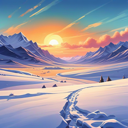

aesthetic_score =0.5857418537139892, vqa_score=0.9996827412971695, score=0.8758858909231034
svg length: 9916


 14%|█▍        | 1/7 [00:00<00:00,  6.32it/s]

result get!


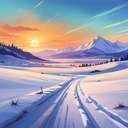

aesthetic_score =0.5495820045471191, vqa_score=0.9992308115003627, score=0.8587164484524178
svg length: 9911


 14%|█▍        | 1/7 [00:00<00:00,  6.33it/s]

result get!


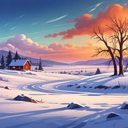

aesthetic_score =0.5983528614044189, vqa_score=0.9997075438458849, score=0.8814572540563019
svg length: 9572


 14%|█▍        | 1/7 [00:00<00:00,  6.29it/s]

result get!


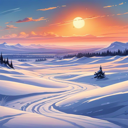

aesthetic_score =0.5804109096527099, vqa_score=0.9997052743142159, score=0.8735002898842064
svg length: 9598


 14%|█▍        | 1/7 [00:00<00:00,  6.38it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.91it/s]

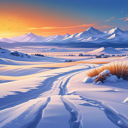

aesthetic_score =0.5560811042785645, vqa_score=0.9996859649311324, score=0.8621350576389983
svg length: 9607


 14%|█▍        | 1/7 [00:00<00:00,  6.36it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.89it/s]

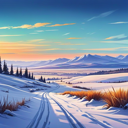

 57%|█████▋    | 4/7 [00:00<00:00,  7.38it/s]

aesthetic_score =0.5648279190063477, vqa_score=0.9996648685127558, score=0.8662821282529867
svg length: 9712


 14%|█▍        | 1/7 [00:00<00:00,  6.37it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.91it/s]

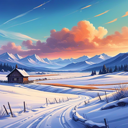

 57%|█████▋    | 4/7 [00:00<00:00,  7.40it/s]

aesthetic_score =0.5535954475402832, vqa_score=0.9997119409921154, score=0.8609518353814732
svg length: 9826


100%|██████████| 7/7 [00:00<00:00,  7.03it/s]


result get!


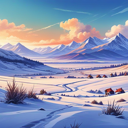

aesthetic_score =0.5643396377563477, vqa_score=0.999633973565818, score=0.8660337263160859
svg length: 9966
result get!


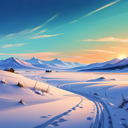

aesthetic_score =0.5606155395507812, vqa_score=0.9997049160843094, score=0.8643140499558459
svg length: 9846
===========9 images in total, takes 56.64s==================
=========== best score: 0.8814572540563019==================


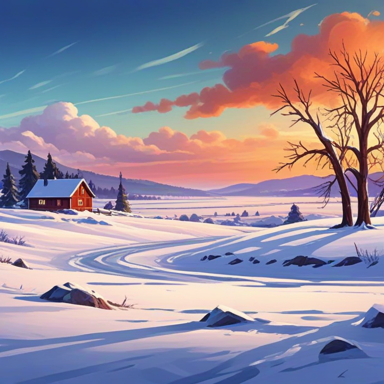

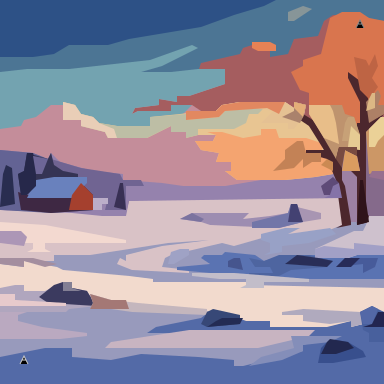

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#A55D5F"/><polygon points="127,39 128,39 128,128 0,128 0,70 29,70 34,71 42,71 43,67 54,66 114,66 114,75 117,75 115,62 114,60 114,53 115,50 119,52 120,57 117,57 119,59 120,74 123,74 122,71 122,44" fill="#989ABC"/><polygon points="64,15 66,16 54,22 47,24 57,24 66,23 75,23 75,28 63,32 59,32 59,34 53,33 53,35 45,36 44,38 46,37 57,37 57,35 64,35 67,37 72,37 74,35 80,34 95,34 98,36 98,34 102,35 101,40 106,45 108,50 107,51 111,54 111,58 105,59 95,60 78,62 75,63 61,63 41,60 37,59 22,56 16,53 0,50 0,24 9,23 23,23 50,20" fill="#C48D9A"/><polygon points="0,0 128,0 128,7 121,6 120,5 111,5 108,7 106,12 98,13 96,18 90,19 90,17 92,17 92,15 84,15 81,16 80,18 67,21 66,24 57,25 45,25 49,22 59,19 62,17 50,21 23,24 0,24" fill="#4C7594"/><polygon points="54,66 114,66 114,75 109,77 94,80 89,80 92,78 78,82 74,81 57,85 55,86 54,89 63,90 63,91 44,90 39,88 40,86 42,87 42,85 54,82 70,80 5

In [22]:
%%time
r = train_df.iloc[10]
description = r.description
# print(description)
svg, img = model.predict_impl(description)
display(img)
display(SVG(svg))
print(svg)

In [23]:
# # Read the last 20 lines of the log using pure Python
# log_path = "/kaggle/working/worker.log"

# try:
#     with open(log_path, "r") as f:
#         lines = f.readlines()[-20:]
#         for line in lines:
#             print(line.rstrip())
# except FileNotFoundError:
#     print("Log file not found.")

In [24]:
# display(img)
# display(SVG(svg))
# print(svg)

In [25]:
# print(img)
# print(svg)

In [26]:
# SVG_check = kagglehub.package_import('metric/svg-constraints/versions/1')
# constraints = SVG_check.SVGConstraints()
# constraints.validate_svg(svg) 

## Evaluate on train dataset (LB prediction!)
This doesn't work, becuase in kaggle reality there is no vram anymore to import metric

  0%|          | 0/15 [00:00<?, ?it/s]

qa={'question': ['Are there a purple forest in the image? Answer yes or no.', 'Are there dusk in the image? Answer yes or no.', 'Are there a purple forest at dusk? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a purple forest at dusk. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.36it/s]

result get!


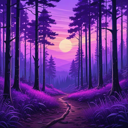

aesthetic_score =0.5268688201904297, vqa_score=0.9995407284617569, score=0.8474800946850389
svg length: 9868


 86%|████████▌ | 6/7 [00:00<00:00,  6.91it/s]

result get!


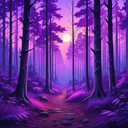

aesthetic_score =0.5472760200500488, vqa_score=0.9993252678243718, score=0.8576428950028555
svg length: 9889


100%|██████████| 7/7 [00:01<00:00,  6.97it/s]


result get!


  0%|          | 0/7 [00:00<?, ?it/s]

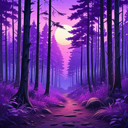

 14%|█▍        | 1/7 [00:00<00:00,  6.32it/s]

aesthetic_score =0.5453835010528565, vqa_score=0.9993334729361526, score=0.8567159620839846
svg length: 9924


 57%|█████▋    | 4/7 [00:00<00:00,  7.32it/s]

result get!


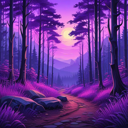

aesthetic_score =0.5477615356445312, vqa_score=0.9993930389531102, score=0.8579211741417284
svg length: 9776


100%|██████████| 7/7 [00:01<00:00,  6.96it/s]


result get!


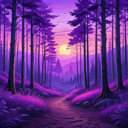

aesthetic_score =0.579471206665039, vqa_score=0.9991573879864779, score=0.8727397780894572
svg length: 9953


100%|██████████| 7/7 [00:01<00:00,  6.93it/s]


result get!


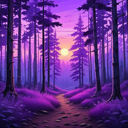

aesthetic_score =0.5707958221435547, vqa_score=0.9994726205313229, score=0.8689530854630418
svg length: 9965
result get!


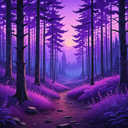

aesthetic_score =0.5226990699768066, vqa_score=0.9992761387826771, score=0.8451593322417468
svg length: 9959
result get!


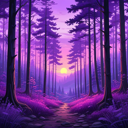

aesthetic_score =0.5442760467529297, vqa_score=0.9994618784618531, score=0.8562440523464697
svg length: 9717
result get!


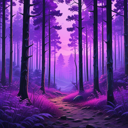

aesthetic_score =0.5321028709411622, vqa_score=0.9991261712624969, score=0.8499304609597282
svg length: 9740
===========9 images in total, takes 19.32s==================
=========== best score: 0.8727397780894572==================
qa={'question': ['Are there a faux fur collar in the image? Answer yes or no.', 'Are there wool coat in the image? Answer yes or no.', 'Are there gray wool coat with a faux fur collar? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a gray wool coat with a faux fur collar. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.31it/s]

result get!


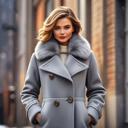

aesthetic_score =0.5178430557250977, vqa_score=0.9919972880376224, score=0.8384540374156758
svg length: 9785


 57%|█████▋    | 4/7 [00:00<00:00,  7.32it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  7.03it/s]

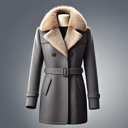

 86%|████████▌ | 6/7 [00:00<00:00,  6.86it/s]

aesthetic_score =0.5141761779785157, vqa_score=0.997847516504572, score=0.839843917986131
svg length: 9519


100%|██████████| 7/7 [00:01<00:00,  6.93it/s]


result get!


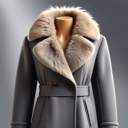

aesthetic_score =0.5001859664916992, vqa_score=0.9923152615643972, score=0.829155300683044
svg length: 9881


 14%|█▍        | 1/7 [00:00<00:00,  6.30it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.81it/s]

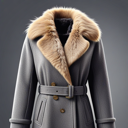

aesthetic_score =0.5246166229248047, vqa_score=0.9904153536037289, score=0.8410622097613852
svg length: 9740


100%|██████████| 7/7 [00:01<00:00,  6.93it/s]


result get!


  0%|          | 0/7 [00:00<?, ?it/s]

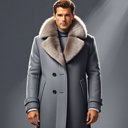

aesthetic_score =0.5554004669189453, vqa_score=0.8074728739753076, score=0.7402768988556157
svg length: 9527


100%|██████████| 7/7 [00:01<00:00,  6.92it/s]


result get!


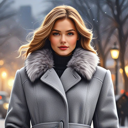

aesthetic_score =0.5633106708526612, vqa_score=0.9953413605217857, score=0.8629704541123913
svg length: 9936
result get!


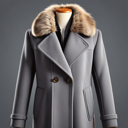

aesthetic_score =0.5190954208374023, vqa_score=0.9696490358440265, score=0.8262234046990895
svg length: 9614
result get!


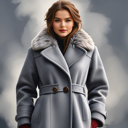

aesthetic_score =0.5152817726135254, vqa_score=0.9936108489058947, score=0.8380253391220966
svg length: 9424
result get!


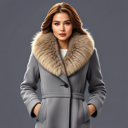

aesthetic_score =0.5126532077789306, vqa_score=0.9890293139441685, score=0.8340275370982574
svg length: 9109
===========9 images in total, takes 20.65s==================
=========== best score: 0.8629704541123913==================
qa={'question': ['Are there a lighthouse in the image? Answer yes or no.', 'Are there the ocean in the image? Answer yes or no.', 'Are there a lighthouse overlooking the ocean? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a lighthouse overlooking the ocean. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.20it/s]

result get!


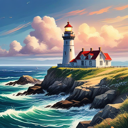

aesthetic_score =0.5943379402160645, vqa_score=0.9995220680843733, score=0.8795914760764431
svg length: 9815


 57%|█████▋    | 4/7 [00:00<00:00,  7.31it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  7.02it/s]

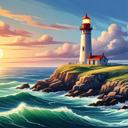

 86%|████████▌ | 6/7 [00:00<00:00,  6.84it/s]

aesthetic_score =0.6114284992218018, vqa_score=0.9996712346259224, score=0.8870234264545466
svg length: 9633


100%|██████████| 7/7 [00:01<00:00,  6.92it/s]


result get!


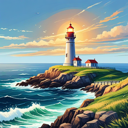

aesthetic_score =0.5865628242492675, vqa_score=0.9996410425601845, score=0.8762270474566034
svg length: 9572


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.70it/s]

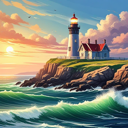

 57%|█████▋    | 4/7 [00:00<00:00,  7.23it/s]

aesthetic_score =0.6277367115020752, vqa_score=0.999648826813075, score=0.8937461412299702
svg length: 9875


 86%|████████▌ | 6/7 [00:00<00:00,  6.81it/s]

result get!


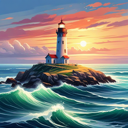

aesthetic_score =0.6093546867370605, vqa_score=0.9996283916774243, score=0.8861214596370562
svg length: 9978


100%|██████████| 7/7 [00:01<00:00,  6.90it/s]


result get!


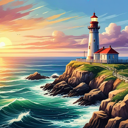

aesthetic_score =0.5831083297729492, vqa_score=0.9996021660565962, score=0.8746550750805188
svg length: 9863
result get!


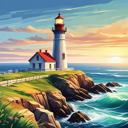

aesthetic_score =0.6112663269042968, vqa_score=0.9996532799807752, score=0.8869438432963194
svg length: 9870
result get!


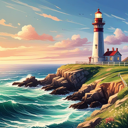

aesthetic_score =0.5653110980987549, vqa_score=0.9996539125265934, score=0.8665027212842041
svg length: 9932
result get!


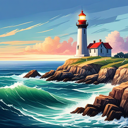

aesthetic_score =0.5901687622070313, vqa_score=0.9996488290171511, score=0.8778343003666933
svg length: 9857
===========9 images in total, takes 18.99s==================
=========== best score: 0.8937461412299702==================
qa={'question': ['Are there burgundy corduroy pants in the image? Answer yes or no.', 'Are there patch pockets in the image? Answer yes or no.', 'Are there burgundy corduroy pants with patch pockets and silver buttons? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a burgundy corduroy pants with patch pockets and silver buttons. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


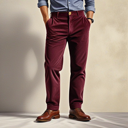

aesthetic_score =0.509884262084961, vqa_score=0.6597963131743851, score=0.6231534071815786
svg length: 9982


 57%|█████▋    | 4/7 [00:00<00:00,  7.27it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.99it/s]

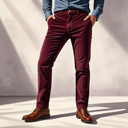

 86%|████████▌ | 6/7 [00:00<00:00,  6.82it/s]

aesthetic_score =0.5026418685913085, vqa_score=0.6527077670187917, score=0.6159300521411623
svg length: 9995


100%|██████████| 7/7 [00:01<00:00,  6.90it/s]


result get!


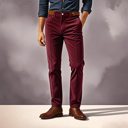

aesthetic_score =0.5438625335693359, vqa_score=0.6485652289124738, score=0.6245191389166062
svg length: 9960


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.79it/s]

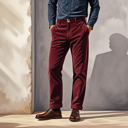

aesthetic_score =0.525142240524292, vqa_score=0.6372370507052012, score=0.6111464636055234
svg length: 9767


 86%|████████▌ | 6/7 [00:00<00:00,  6.80it/s]

result get!


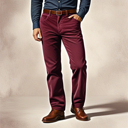

aesthetic_score =0.5151479721069336, vqa_score=0.8547567910011368, score=0.7551862160363051
svg length: 9625


100%|██████████| 7/7 [00:01<00:00,  6.89it/s]


result get!


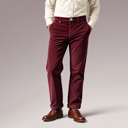

aesthetic_score =0.5329059600830078, vqa_score=0.650433083052428, score=0.6229557412724165
svg length: 9695
result get!


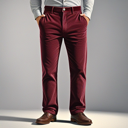

aesthetic_score =0.5145985603332519, vqa_score=0.6555438161532786, score=0.6214989010108382
svg length: 9833
result get!


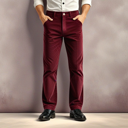

aesthetic_score =0.5261694908142089, vqa_score=0.5945245384270845, score=0.5794687013397029
svg length: 9940
result get!


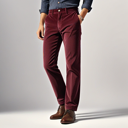

aesthetic_score =0.5149287223815918, vqa_score=0.6525524643637624, score=0.6194411592202556
svg length: 9922
===========9 images in total, takes 18.81s==================
=========== best score: 0.7551862160363051==================
qa={'question': ['Are there orange corduroy overalls in the image? Answer yes or no.', 'Are there orange corduroy overalls? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes']}
============== a stylized digital painting presenting a orange corduroy overalls. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


100%|██████████| 7/7 [00:01<00:00,  6.90it/s]


result get!


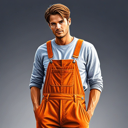

aesthetic_score =0.5121066093444824, vqa_score=0.9992597754132627, score=0.8395344856919416
svg length: 9950


 14%|█▍        | 1/7 [00:00<00:00,  6.25it/s]

result get!


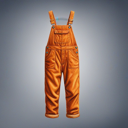

aesthetic_score =0.4202312469482422, vqa_score=0.9982121981049034, score=0.7828638991250217
svg length: 9500


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.78it/s]

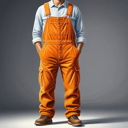

 57%|█████▋    | 4/7 [00:00<00:00,  7.27it/s]

aesthetic_score =0.5005026817321777, vqa_score=0.9990836341538425, score=0.8331028251780002
svg length: 9915


 57%|█████▋    | 4/7 [00:00<00:00,  7.26it/s]

result get!


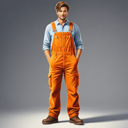

aesthetic_score =0.5005974292755127, vqa_score=0.9991906402705432, score=0.8332148507152182
svg length: 9928


 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

result get!


100%|██████████| 7/7 [00:01<00:00,  6.89it/s]


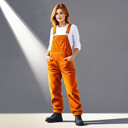

aesthetic_score =0.5054918766021729, vqa_score=0.9992887777274038, score=0.8359641023723275
svg length: 9976


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


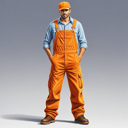

aesthetic_score =0.497970724105835, vqa_score=0.9987207009921366, score=0.8314938012552792
svg length: 9861


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


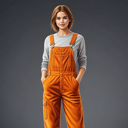

aesthetic_score =0.5119951725006103, vqa_score=0.9992985006177598, score=0.8394964428895336
svg length: 9385
result get!


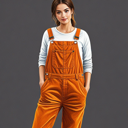

aesthetic_score =0.4805564880371094, vqa_score=0.9992861673449733, score=0.8218577084092885
svg length: 9898
result get!


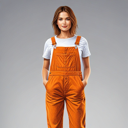

aesthetic_score =0.49353938102722167, vqa_score=0.9993399528341342, score=0.8293493194159226
svg length: 9738
===========9 images in total, takes 16.41s==================
=========== best score: 0.8395344856919416==================
qa={'question': ['Are there a purple silk scarf in the image? Answer yes or no.', 'Are there tassel trim in the image? Answer yes or no.', 'Are there a purple silk scarf with tassel trim? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a purple silk scarf with tassel trim. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.24it/s]

result get!


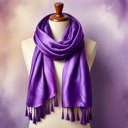

aesthetic_score =0.5213083744049072, vqa_score=0.9897184957666568, score=0.8389538133543322
svg length: 9943


 57%|█████▋    | 4/7 [00:00<00:00,  7.24it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.97it/s]

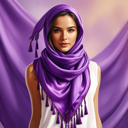

 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

aesthetic_score =0.5325627803802491, vqa_score=0.6690590704558047, score=0.6364352900614904
svg length: 9990


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


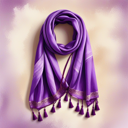

aesthetic_score =0.467113733291626, vqa_score=0.9995181496484925, score=0.8139697286084379
svg length: 9866


 14%|█▍        | 1/7 [00:00<00:00,  6.23it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.74it/s]

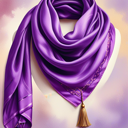

 57%|█████▋    | 4/7 [00:00<00:00,  7.23it/s]

aesthetic_score =0.49101696014404295, vqa_score=0.9801202320633599, score=0.8172977490734282
svg length: 9933


 86%|████████▌ | 6/7 [00:00<00:00,  6.77it/s]

result get!


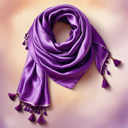

aesthetic_score =0.46807060241699217, vqa_score=0.9986469495544287, score=0.8140870442845731
svg length: 9728


100%|██████████| 7/7 [00:01<00:00,  6.86it/s]


result get!


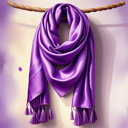

aesthetic_score =0.475618839263916, vqa_score=0.7294497077351644, score=0.6590993564666222
svg length: 9838
result get!


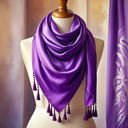

aesthetic_score =0.5245068550109864, vqa_score=0.999560668763055, score=0.8462655584518134
svg length: 9935
result get!


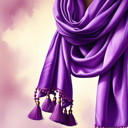

aesthetic_score =0.49950180053710935, vqa_score=0.9995391399006619, score=0.832800469310503
svg length: 9969
result get!


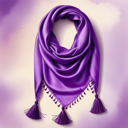

aesthetic_score =0.46663317680358884, vqa_score=0.9989601074946084, score=0.8133817786376275
svg length: 9961
===========9 images in total, takes 19.05s==================
=========== best score: 0.8462655584518134==================
qa={'question': ['Are there a cloudy sky in the image? Answer yes or no.', 'Are there a green lagoon in the image? Answer yes or no.', 'Are there a green lagoon under a cloudy sky? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a green lagoon under a cloudy sky. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.25it/s]

result get!


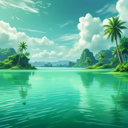

aesthetic_score =0.5412453174591064, vqa_score=0.9995502725307045, score=0.8547898754195034
svg length: 9837


 57%|█████▋    | 4/7 [00:00<00:00,  7.25it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.97it/s]

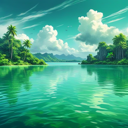

 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

aesthetic_score =0.5832362651824952, vqa_score=0.9994793492618314, score=0.87463739768959
svg length: 9877


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


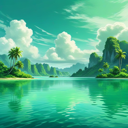

aesthetic_score =0.5770977020263672, vqa_score=0.9994424215528972, score=0.8718334401118136
svg length: 9759


 14%|█▍        | 1/7 [00:00<00:00,  6.24it/s]

result get!


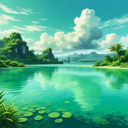

aesthetic_score =0.5640807151794434, vqa_score=0.9993407403308165, score=0.8657356972203778
svg length: 9905


 57%|█████▋    | 4/7 [00:00<00:00,  7.22it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.93it/s]

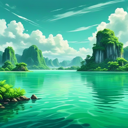

 86%|████████▌ | 6/7 [00:00<00:00,  6.76it/s]

aesthetic_score =0.5831696510314941, vqa_score=0.9994537133431425, score=0.874591729411197
svg length: 9793


100%|██████████| 7/7 [00:01<00:00,  6.84it/s]


result get!


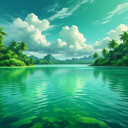

aesthetic_score =0.563665771484375, vqa_score=0.999521735154159, score=0.8656487276160171
svg length: 9646
result get!


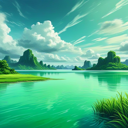

aesthetic_score =0.5927393913269043, vqa_score=0.9995623522473192, score=0.8789148184208998
svg length: 9866
result get!


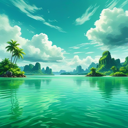

aesthetic_score =0.568822717666626, vqa_score=0.999447511162825, score=0.8680211717358692
svg length: 9781
result get!


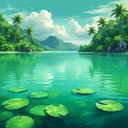

aesthetic_score =0.5631242752075195, vqa_score=0.9993649469576827, score=0.8652991011814231
svg length: 9688
===========9 images in total, takes 18.82s==================
=========== best score: 0.8789148184208998==================
qa={'question': ['Are there crimson rectangles in the image? Answer yes or no.', 'Are there a chaotic grid in the image? Answer yes or no.', 'Are there crimson rectangles forming a chaotic grid? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a crimson rectangles forming a chaotic grid. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.25it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.77it/s]

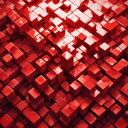

aesthetic_score =0.42876472473144533, vqa_score=0.9992754677570639, score=0.7892433521138964
svg length: 9868


 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

result get!


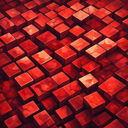

aesthetic_score =0.45844597816467286, vqa_score=0.9995072778444766, score=0.8086357187888348
svg length: 9377


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


  0%|          | 0/7 [00:00<?, ?it/s]

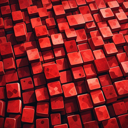

 14%|█▍        | 1/7 [00:00<00:00,  6.22it/s]

aesthetic_score =0.4530620574951172, vqa_score=0.9995338834823501, score=0.80527377213609
svg length: 9789


 57%|█████▋    | 4/7 [00:00<00:00,  7.23it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.95it/s]

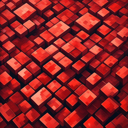

aesthetic_score =0.45897469520568845, vqa_score=0.9995358004726533, score=0.8089794107672876
svg length: 9974


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


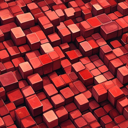

aesthetic_score =0.446379280090332, vqa_score=0.9995385071596296, score=0.8010132272396113
svg length: 9933


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


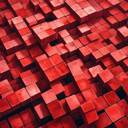

aesthetic_score =0.4255488395690918, vqa_score=0.9996066641266823, score=0.7872180352546627
svg length: 9700
result get!


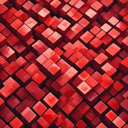

aesthetic_score =0.4214958190917969, vqa_score=0.9995536656081969, score=0.7844012205280562
svg length: 9345
result get!


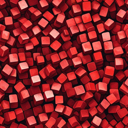

aesthetic_score =0.46324872970581055, vqa_score=0.9993622016741724, score=0.8115275382502406
svg length: 9990
result get!


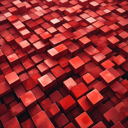

aesthetic_score =0.4475536823272705, vqa_score=0.9995298493681734, score=0.8017638390623806
svg length: 9769
===========9 images in total, takes 19.58s==================
=========== best score: 0.8115275382502406==================
qa={'question': ['Are there purple pyramids in the image? Answer yes or no.', 'Are there a bronze cone in the image? Answer yes or no.', 'Are there purple pyramids spiraling around a bronze cone? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a purple pyramids spiraling around a bronze cone. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


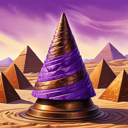

aesthetic_score =0.5500021934509277, vqa_score=0.9929574952137653, score=0.8552060284356874
svg length: 9960


 57%|█████▋    | 4/7 [00:00<00:00,  7.23it/s]

result get!


 86%|████████▌ | 6/7 [00:00<00:00,  6.78it/s]

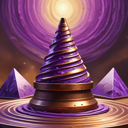

aesthetic_score =0.5303226470947265, vqa_score=0.9870652443036033, score=0.8420256260727742
svg length: 9446


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


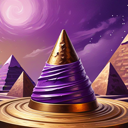

aesthetic_score =0.556041145324707, vqa_score=0.9991675483362469, score=0.8618073558728577
svg length: 9950


 14%|█▍        | 1/7 [00:00<00:00,  6.22it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.72it/s]

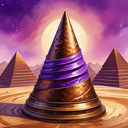

 57%|█████▋    | 4/7 [00:00<00:00,  7.21it/s]

aesthetic_score =0.5399945735931396, vqa_score=0.9965260692380549, score=0.8523965245166272
svg length: 9836


 86%|████████▌ | 6/7 [00:00<00:00,  6.77it/s]

result get!


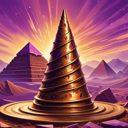

aesthetic_score =0.5358122825622559, vqa_score=0.9991747498410759, score=0.8518425963838587
svg length: 9619


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


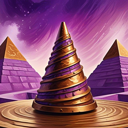

aesthetic_score =0.49651947021484377, vqa_score=0.993014614132788, score=0.8275189356383283
svg length: 9967
result get!


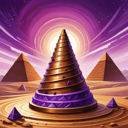

aesthetic_score =0.5537264823913575, vqa_score=0.9971536950323227, score=0.8594958881296272
svg length: 9920
result get!


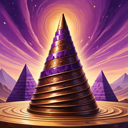

aesthetic_score =0.5203927993774414, vqa_score=0.9993318284218515, score=0.8439815913098575
svg length: 9957
result get!


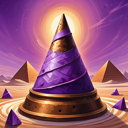

aesthetic_score =0.5298697471618652, vqa_score=0.9976821369902605, score=0.8479535711629073
svg length: 9994
===========9 images in total, takes 19.19s==================
=========== best score: 0.8618073558728577==================
qa={'question': ['Are there a transluscent silver sheet in the image? Answer yes or no.', 'Are there magenta trapezoids in the image? Answer yes or no.', 'Are there magenta trapezoids layered on a transluscent silver sheet? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a magenta trapezoids layered on a transluscent silver sheet. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.26it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.75it/s]

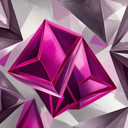

aesthetic_score =0.4920863151550293, vqa_score=0.9501358716752635, score=0.8010140185856979
svg length: 9743


 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

result get!


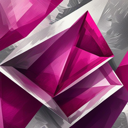

aesthetic_score =0.5019021511077881, vqa_score=0.9825907617214142, score=0.8246346757827778
svg length: 9995


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


  0%|          | 0/7 [00:00<?, ?it/s]

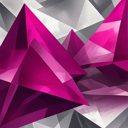

 14%|█▍        | 1/7 [00:00<00:00,  6.24it/s]

aesthetic_score =0.4797001838684082, vqa_score=0.9765964841325642, score=0.8089969656518305
svg length: 9921


 57%|█████▋    | 4/7 [00:00<00:00,  7.22it/s]

result get!


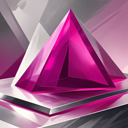

aesthetic_score =0.5246922492980957, vqa_score=0.9255403880574881, score=0.8028673759281957
svg length: 9844


 86%|████████▌ | 6/7 [00:00<00:00,  6.77it/s]

result get!


100%|██████████| 7/7 [00:01<00:00,  6.86it/s]


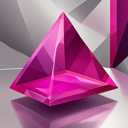

aesthetic_score =0.4924939155578613, vqa_score=0.8408512677314769, score=0.7366411087649734
svg length: 9815


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


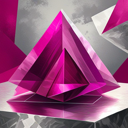

aesthetic_score =0.4974660873413086, vqa_score=0.9578921746684953, score=0.8082737979579162
svg length: 9672
result get!


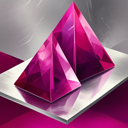

aesthetic_score =0.5132308959960937, vqa_score=0.8699064967879603, score=0.7637510194594233
svg length: 9824
result get!


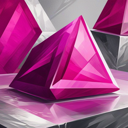

aesthetic_score =0.5470808029174805, vqa_score=0.9582703595687997, score=0.8330458094696661
svg length: 9817
result get!


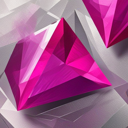

aesthetic_score =0.477793025970459, vqa_score=0.986263229449929, score=0.8131841414738514
svg length: 9869
===========9 images in total, takes 19.36s==================
=========== best score: 0.8330458094696661==================
qa={'question': ['Are there a snowy plain in the image? Answer yes or no.', 'Are there a snowy plain? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes']}
============== a stylized digital painting presenting a a snowy plain. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


100%|██████████| 7/7 [00:01<00:00,  6.90it/s]


result get!


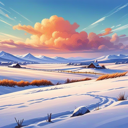

aesthetic_score =0.5617194652557373, vqa_score=0.9996743985111868, score=0.8648198514477823
svg length: 9732


100%|██████████| 7/7 [00:01<00:00,  6.89it/s]


result get!


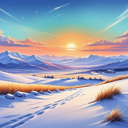

aesthetic_score =0.5504854202270508, vqa_score=0.9994091085289027, score=0.8592625102230831
svg length: 9962


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


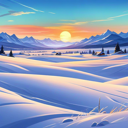

aesthetic_score =0.5684545516967774, vqa_score=0.9996794064023771, score=0.8679894961849012
svg length: 9910


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


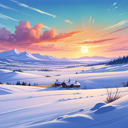

aesthetic_score =0.5573864936828613, vqa_score=0.9996805921781442, score=0.8627583858419661
svg length: 9819


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


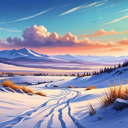

aesthetic_score =0.5496424674987793, vqa_score=0.9995451907654052, score=0.8589317060065188
svg length: 9962


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


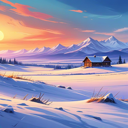

aesthetic_score =0.5804462909698487, vqa_score=0.9996253864411839, score=0.8734675209950843
svg length: 9901


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


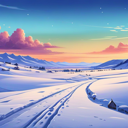

aesthetic_score =0.54910306930542, vqa_score=0.9997152869371567, score=0.858768496358834
svg length: 9916


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


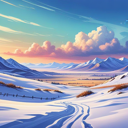

aesthetic_score =0.546325397491455, vqa_score=0.9996885848374244, score=0.8573892437717099
svg length: 9714
result get!


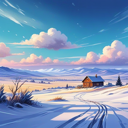

aesthetic_score =0.5618133544921875, vqa_score=0.9991774898692882, score=0.8645667707901116
svg length: 9872
===========9 images in total, takes 14.52s==================
=========== best score: 0.8734675209950843==================
qa={'question': ['Are there black and white checkered pants in the image? Answer yes or no.', 'Are there black and white checkered pants? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes']}
============== a stylized digital painting presenting a black and white checkered pants. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


100%|██████████| 7/7 [00:01<00:00,  6.85it/s]


result get!


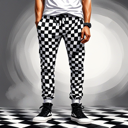

aesthetic_score =0.41862173080444337, vqa_score=0.6182013457528539, score=0.5643866216947336
svg length: 9613


100%|██████████| 7/7 [00:01<00:00,  6.84it/s]


result get!


  0%|          | 0/7 [00:00<?, ?it/s]

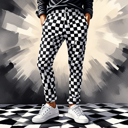

 14%|█▍        | 1/7 [00:00<00:00,  6.19it/s]

aesthetic_score =0.44136981964111327, vqa_score=0.3727032876722115, score=0.38467244438594456
svg length: 9330


 57%|█████▋    | 4/7 [00:00<00:00,  7.19it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.92it/s]

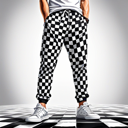

 86%|████████▌ | 6/7 [00:00<00:00,  6.75it/s]

aesthetic_score =0.39186921119689944, vqa_score=0.04136496357759345, score=0.05037678522542655
svg length: 7186


100%|██████████| 7/7 [00:01<00:00,  6.83it/s]


result get!


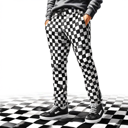

aesthetic_score =0.38175430297851565, vqa_score=0.1941175924490463, score=0.21528013382041636
svg length: 9340
result get!


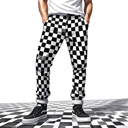

aesthetic_score =0.4252500057220459, vqa_score=0.6278157430065456, score=0.573206889561208
svg length: 9863
result get!


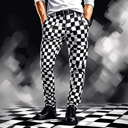

aesthetic_score =0.4224385738372803, vqa_score=0.9905743311558622, score=0.78060728000907
svg length: 9792
result get!


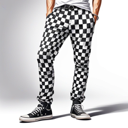

aesthetic_score =0.4059158802032471, vqa_score=0.9254570739915446, score=0.7368378795911869
svg length: 8342
result get!


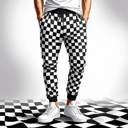

aesthetic_score =0.3807614803314209, vqa_score=0.9581558035928388, score=0.7351857337922247
svg length: 7296
result get!


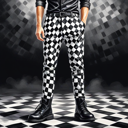

aesthetic_score =0.4073043346405029, vqa_score=0.253611471454399, score=0.27431344551455145
svg length: 8033
===========9 images in total, takes 33.20s==================
=========== best score: 0.78060728000907==================
qa={'question': ['Are there snow-covered peaks in the image? Answer yes or no.', 'Are there a starlit night in the image? Answer yes or no.', 'Are there a starlit night over snow-covered peaks? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a starlit night over snow-covered peaks. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.23it/s]

result get!


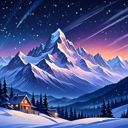

aesthetic_score =0.6076952457427979, vqa_score=0.7413993558771261, score=0.7101501422313142
svg length: 9925


 57%|█████▋    | 4/7 [00:00<00:00,  7.26it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.99it/s]

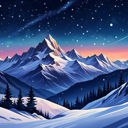

 86%|████████▌ | 6/7 [00:00<00:00,  6.82it/s]

aesthetic_score =0.5787416458129883, vqa_score=0.7466934568593135, score=0.7057325021050407
svg length: 9865


100%|██████████| 7/7 [00:01<00:00,  6.91it/s]


result get!


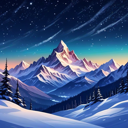

aesthetic_score =0.5668166637420654, vqa_score=0.674015926344576, score=0.6494504491117709
svg length: 9674


 14%|█▍        | 1/7 [00:00<00:00,  6.24it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.78it/s]

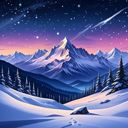

 57%|█████▋    | 4/7 [00:00<00:00,  7.27it/s]

aesthetic_score =0.610419225692749, vqa_score=0.8568553060299658, score=0.7928389346054985
svg length: 9929


 86%|████████▌ | 6/7 [00:00<00:00,  6.80it/s]

result get!


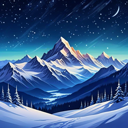

aesthetic_score =0.6107299327850342, vqa_score=0.6399361954930414, score=0.6338735882591235
svg length: 9821


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


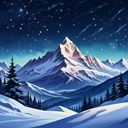

aesthetic_score =0.5897060394287109, vqa_score=0.6802308336210664, score=0.6599686941098057
svg length: 9954
result get!


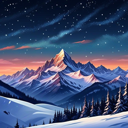

aesthetic_score =0.6037775993347168, vqa_score=0.8094731371948333, score=0.7578370078914921
svg length: 9961
result get!


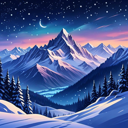

aesthetic_score =0.6199709892272949, vqa_score=0.6743035188183214, score=0.662688287900229
svg length: 9958
result get!


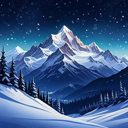

aesthetic_score =0.6021102428436279, vqa_score=0.6638390846415466, score=0.6505011020722588
svg length: 9482
===========9 images in total, takes 18.90s==================
=========== best score: 0.7928389346054985==================
qa={'question': ['Are there azure crescents in the image? Answer yes or no.', 'Are there khaki triangles in the image? Answer yes or no.', 'Are there khaki triangles and azure crescents? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a khaki triangles and azure crescents. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.27it/s]

result get!


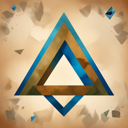

aesthetic_score =0.5054733276367187, vqa_score=0.8687442504579097, score=0.7595678079260587
svg length: 9664


 57%|█████▋    | 4/7 [00:00<00:00,  7.27it/s]

result get!


 86%|████████▌ | 6/7 [00:00<00:00,  6.80it/s]

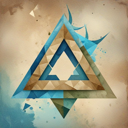

aesthetic_score =0.49145827293395994, vqa_score=0.9730840817180704, score=0.813616366157505
svg length: 9869


100%|██████████| 7/7 [00:01<00:00,  6.90it/s]


result get!


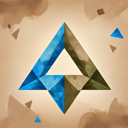

aesthetic_score =0.5074811935424804, vqa_score=0.9805159782764769, score=0.8264461251045316
svg length: 9735


 14%|█▍        | 1/7 [00:00<00:00,  6.26it/s]

result get!


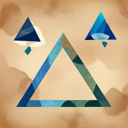

aesthetic_score =0.4731874465942383, vqa_score=0.9057606873901791, score=0.7657548379918353
svg length: 9996


 57%|█████▋    | 4/7 [00:00<00:00,  7.26it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.98it/s]

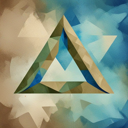

 86%|████████▌ | 6/7 [00:00<00:00,  6.80it/s]

aesthetic_score =0.5064467906951904, vqa_score=0.9339333522333811, score=0.7990409002512464
svg length: 9397


100%|██████████| 7/7 [00:01<00:00,  6.89it/s]


result get!


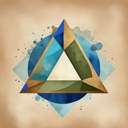

aesthetic_score =0.5278975963592529, vqa_score=0.893150371792246, score=0.7845800562363217
svg length: 9910
result get!


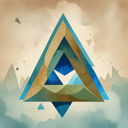

aesthetic_score =0.5209213733673096, vqa_score=0.965603228985365, score=0.8247880177218173
svg length: 9938
result get!


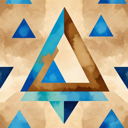

aesthetic_score =0.4867862701416016, vqa_score=0.9821595450104426, score=0.8160670239365364
svg length: 9987
result get!


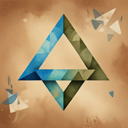

aesthetic_score =0.504575252532959, vqa_score=0.951688865115772, score=0.8084179906649711
svg length: 9838
===========9 images in total, takes 18.97s==================
=========== best score: 0.8264461251045316==================
qa={'question': ['Are there a maroon dodecahedron in the image? Answer yes or no.', 'Are there teal threads in the image? Answer yes or no.', 'Are there a maroon dodecahedron interwoven with teal threads? Answer yes or no.'], 'choices': [['no', 'yes'], ['no', 'yes'], ['no', 'yes']], 'answer': ['yes', 'yes', 'yes']}
============== a stylized digital painting presenting a a maroon dodecahedron interwoven with teal threads. The painting promote vector-art aesthetic, in watercolor art style with vibrant and clean background. The overall atmosphere is tranquil yet powerful, raw-photo hyper-detail, 4K, cinematic lighting, award-winning, masterpiece. =====================


 14%|█▍        | 1/7 [00:00<00:00,  6.23it/s]

result get!


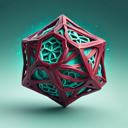

aesthetic_score =0.5223786354064941, vqa_score=0.9970002425818689, score=0.843688857225945
svg length: 9691


 57%|█████▋    | 4/7 [00:00<00:00,  7.24it/s]

result get!


 71%|███████▏  | 5/7 [00:00<00:00,  6.96it/s]

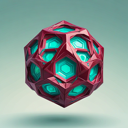

 86%|████████▌ | 6/7 [00:00<00:00,  6.79it/s]

aesthetic_score =0.5217418193817138, vqa_score=0.9985090771743822, score=0.8442196320842694
svg length: 9897


100%|██████████| 7/7 [00:01<00:00,  6.88it/s]


result get!


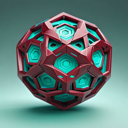

aesthetic_score =0.4907975673675537, vqa_score=0.99398210391732, score=0.8248487693848275
svg length: 9967


 14%|█▍        | 1/7 [00:00<00:00,  6.22it/s]

result get!


 43%|████▎     | 3/7 [00:00<00:00,  7.74it/s]

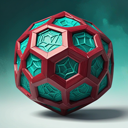

aesthetic_score =0.5067831993103027, vqa_score=0.9981192559748604, score=0.8360131006248276
svg length: 9831


 86%|████████▌ | 6/7 [00:00<00:00,  6.78it/s]

result get!


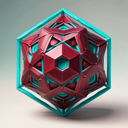

aesthetic_score =0.4930866718292236, vqa_score=0.9975140986928668, score=0.8280874803024805
svg length: 9921


100%|██████████| 7/7 [00:01<00:00,  6.87it/s]


result get!


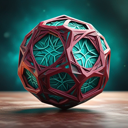

aesthetic_score =0.4688398838043213, vqa_score=0.883029474214054, score=0.7504370026685556
svg length: 9946
result get!


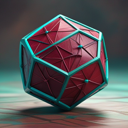

aesthetic_score =0.5148412704467773, vqa_score=0.9990126829846971, score=0.840859106459435
svg length: 9932
result get!


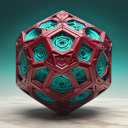

aesthetic_score =0.4977911949157715, vqa_score=0.9987312495544852, score=0.8313995156640127
svg length: 9794
result get!


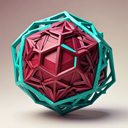

aesthetic_score =0.49240884780883787, vqa_score=0.9990447329129835, score=0.8285474441007674
svg length: 9994
===========9 images in total, takes 18.91s==================
=========== best score: 0.8442196320842694==================


  0%|          | 0/15 [00:00<?, ?it/s]

AttributeError: module 'metricMP' has no attribute 'aesthetic_evaluator'

In [27]:
# %%time

# import matplotlib.pyplot as plt
# %matplotlib inline

# import pandas as pd
# from tqdm.auto import tqdm
# tqdm.pandas()



# train_df['raw_res'] = train_df.description.progress_apply(model.predict_impl)
# train_df['svg'] = train_df.raw_res.apply(lambda x: x[0])
# train_df['bitmap'] = train_df.raw_res.apply(lambda x: x[1])
# train_df['bitmap_score'] = train_df.progress_apply(
#     lambda r: bitmap_score_instance(r.multiple_choice_qa, r.bitmap, random_seed=42),
#     axis=1,
# )

# train_df['svg_score'] = train_df.progress_apply(
#     lambda r: metric.score_instance(r.multiple_choice_qa, r.svg, random_seed=42),
#     axis=1,
# )

# for r in train_df.itertuples():
#     b_score = r.bitmap_score['competition_score']
#     b_vqa = r.bitmap_score['vqa_score']
#     b_ocr = r.bitmap_score['ocr_score']
#     b_aesthetic = r.bitmap_score['aesthetic_score']

#     s_score = r.svg_score['competition_score']
#     s_vqa = r.svg_score['vqa_score']
#     s_ocr = r.svg_score['ocr_score']
#     s_aesthetic = r.svg_score['aesthetic_score']
    
#     plt.figure(figsize=(12, 6))
#     plt.suptitle(r.description, y=0.93)
    
#     plt.subplot(1, 2, 1)
#     plt.imshow(np.array(r.bitmap))
#     plt.axis('off')
#     plt.title(f'bitmap: score={b_score:.2f}, vqa={b_vqa:.2f}, ocr={b_ocr:.2f}, aes={b_aesthetic:.2f}')

#     plt.subplot(1, 2, 2)
#     plt.imshow(metric.svg_to_png(r.svg))
#     plt.axis('off')
#     plt.title(f'svg: score={s_score:.2f}, vqa={s_vqa:.2f}, ocr={s_ocr:.2f}, aes={s_aesthetic:.2f}')


# mean_bitmap_score = pd.DataFrame(train_df['bitmap_score'].tolist()).mean(axis=0)
# print(mean_bitmap_score)


# mean_svg_score = pd.DataFrame(train_df['svg_score'].tolist()).mean(axis=0)
# print(mean_svg_score)


# print(f'Original bitmap score: {mean_bitmap_score.competition_score}')
# print(f'Final svg score: {mean_svg_score.competition_score}')